# Allen-Cahn Latent SDMD-KSWGD

## Methodology Summary

This notebook implements a single-target latent-space SDMD-KSWGD experiment for the stochastic Allen-Cahn equation.

1. Generate a late-time Allen-Cahn snapshot trajectory. This late-time trajectory defines the target distribution.
2. Train an autoencoder on late-time target fields and a small pool of initial-condition fields. The initial pool helps the decoder represent iteration-0 particles sensibly.
3. Encode fields into latent variables and standardize the latent coordinates before SDMD and KSWGD.
4. Construct consecutive target pairs `Z_tar = Z[:-1]` and `Z_tar_next = Z[1:]` from the latent trajectory.
5. Train the SDMD/Koopman generator spectrum on `(Z_tar, Z_tar_next)` in standardized latent space.
6. Initialize KSWGD particles from encoded initial-condition fields, rather than from the target distribution.
7. Build a single target kernel on `Z_tar`, with bandwidth widened using init-target distances so initial particles have nonzero kernel overlap.
8. Run KSWGD toward this fixed target distribution. Adaptive step stabilization rescales the raw latent KSWGD force to make transport visible while recording the raw force and effective step size.
9. Decode sampled latent particles back to Allen-Cahn fields and compare pixel-value distributions against the target.

## Parameter Configuration

This notebook uses the lower-noise Allen-Cahn parameter configuration:

- Spatial grid: `N = 128`
- PDE time step: `dt = 1e-5`
- Interface width: `epsilon = 0.02`
- Noise intensity: `sigma = 0.1`
- Target trajectory window: `t = 0.0005` to `t = 0.003`
- Target snapshots: `251`, forming `250` consecutive latent training pairs
- Latent dimension: `8`
- KSWGD particles: `100`
- KSWGD iterations: `500`


In [1]:
# ============================================================
# Setup
# ============================================================

import os
import time
import random
import warnings
from pathlib import Path

import numpy as np
try:
    import matplotlib.pyplot as plt
except ImportError:
    import sys
    import types
    import importlib.machinery
    plt = None
    matplotlib_stub = types.ModuleType('matplotlib')
    pyplot_stub = types.ModuleType('matplotlib.pyplot')
    matplotlib_stub.__spec__ = importlib.machinery.ModuleSpec('matplotlib', loader=None)
    pyplot_stub.__spec__ = importlib.machinery.ModuleSpec('matplotlib.pyplot', loader=None)
    matplotlib_stub.pyplot = pyplot_stub
    sys.modules['matplotlib'] = matplotlib_stub
    sys.modules['matplotlib.pyplot'] = pyplot_stub
    print('Warning: matplotlib is not installed; plotting cells will be skipped.')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

# `solver_sdmd_torch_gpu` imports sklearn.model_selection.train_test_split.
# Keep a tiny fallback so this notebook can still run in lean environments.
try:
    import sklearn.model_selection  # noqa: F401
except ImportError:
    import sys
    import types
    import importlib.machinery

    sklearn_stub = types.ModuleType('sklearn')
    model_selection_stub = types.ModuleType('sklearn.model_selection')
    sklearn_stub.__spec__ = importlib.machinery.ModuleSpec('sklearn', loader=None)
    model_selection_stub.__spec__ = importlib.machinery.ModuleSpec('sklearn.model_selection', loader=None)

    def train_test_split(*arrays, test_size=0.25, random_state=None, shuffle=True):
        if not arrays:
            raise ValueError('At least one array is required.')
        n = len(arrays[0])
        rng = np.random.default_rng(random_state)
        indices = np.arange(n)
        if shuffle:
            rng.shuffle(indices)
        n_test = int(np.ceil(n * test_size)) if isinstance(test_size, float) else int(test_size)
        test_idx = indices[:n_test]
        train_idx = indices[n_test:]
        result = []
        for arr in arrays:
            result.extend([arr[train_idx], arr[test_idx]])
        return result

    model_selection_stub.train_test_split = train_test_split
    sklearn_stub.model_selection = model_selection_stub
    sys.modules['sklearn'] = sklearn_stub
    sys.modules['sklearn.model_selection'] = model_selection_stub

torch.set_default_dtype(torch.float64)

try:
    from tqdm.auto import tqdm, trange
except ImportError:
    import sys
    import types
    import importlib.machinery

    class _SimpleTqdm:
        def __init__(self, iterable=None, **kwargs):
            self.iterable = iterable if iterable is not None else []
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix(self, *args, **kwargs):
            pass
        def close(self):
            pass

    def tqdm(iterable=None, **kwargs):
        return _SimpleTqdm(iterable, **kwargs)

    def trange(*args, **kwargs):
        return _SimpleTqdm(range(*args), **kwargs)

    tqdm_stub = types.ModuleType('tqdm')
    tqdm_auto_stub = types.ModuleType('tqdm.auto')
    tqdm_stub.__spec__ = importlib.machinery.ModuleSpec('tqdm', loader=None)
    tqdm_auto_stub.__spec__ = importlib.machinery.ModuleSpec('tqdm.auto', loader=None)
    tqdm_stub.tqdm = tqdm
    tqdm_auto_stub.tqdm = tqdm
    tqdm_auto_stub.trange = trange
    sys.modules['tqdm'] = tqdm_stub
    sys.modules['tqdm.auto'] = tqdm_auto_stub

# Fallbacks for optional imports used by solver_sdmd_torch_gpu.
try:
    import joblib  # noqa: F401
except ImportError:
    import pickle
    import sys
    import types
    import importlib.machinery
    joblib_stub = types.ModuleType('joblib')
    joblib_stub.__spec__ = importlib.machinery.ModuleSpec('joblib', loader=None)
    def dump(obj, filename):
        with open(filename, 'wb') as f:
            pickle.dump(obj, f)
    joblib_stub.dump = dump
    sys.modules['joblib'] = joblib_stub

try:
    import functorch  # noqa: F401
except ImportError:
    import sys
    import types
    import importlib.machinery
    import torch.func as torch_func
    functorch_stub = types.ModuleType('functorch')
    functorch_stub.__spec__ = importlib.machinery.ModuleSpec('functorch', loader=None)
    functorch_stub.vmap = torch_func.vmap
    functorch_stub.jacrev = torch_func.jacrev
    sys.modules['functorch'] = functorch_stub

import solver_sdmd_torch_gpu
from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch

RANDOM_SEED = 5
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device_compute = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = str(device_compute)
solver_sdmd_torch_gpu.device = device

FIG_DIR = Path('figures/allen_cahn')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def gaussian_filter1d(values, sigma=2.0):
    """Small numpy-only Gaussian smoother used for histogram display."""
    values = np.asarray(values, dtype=float)
    if sigma <= 0:
        return values
    radius = max(1, int(4 * sigma + 0.5))
    x = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (x / sigma) ** 2)
    kernel /= kernel.sum()
    padded = np.pad(values, radius, mode='edge')
    return np.convolve(padded, kernel, mode='valid')


print('=' * 70)
print('Allen-Cahn latent SDMD + KSWGD setup')
print('=' * 70)
print(f'Device: {device_compute}')
print(f'Random seed: {RANDOM_SEED}')
print('=' * 70)


Allen-Cahn latent SDMD + KSWGD setup
Device: cuda
Random seed: 5


In [2]:
# --- Plot polish settings (visual only) ---
# This cell only controls figure appearance. It does not change sampling, kernels, spectra, or metrics.
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

PAPER_DPI = 160
EXPORT_DPI = 300

plt.rcParams.update({
    'figure.dpi': PAPER_DPI,
    'savefig.dpi': EXPORT_DPI,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
    'font.family': 'DejaVu Sans',
    'mathtext.fontset': 'dejavusans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 0.9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'image.interpolation': 'nearest',
})

def polish_axes(ax, *, equal=False, grid=False):
    """Apply consistent visual-only axis styling."""
    if equal:
        ax.set_aspect('equal', adjustable='box')
    ax.tick_params(direction='in', length=3, width=0.8)
    if grid:
        ax.grid(True, alpha=0.22, linestyle='--', linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color('0.25')
    return ax

def polish_legend(ax, **kwargs):
    """Draw a compact legend only when labelled artists exist."""
    handles, labels = ax.get_legend_handles_labels()
    labels = [label for label in labels if label and not label.startswith('_')]
    if labels:
        defaults = dict(frameon=True, framealpha=0.92, edgecolor='0.85')
        defaults.update(kwargs)
        return ax.legend(**defaults)
    return None

def set_pi_ticks(ax):
    ticks = [0, np.pi, 2 * np.pi]
    labels = ['0', r'$\pi$', r'$2\pi$']
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
    return ax


In [3]:
# ============================================================
# Stochastic Allen-Cahn PDE and trajectory generation
# ============================================================

class StochasticAllenCahn2D:
    """2D stochastic Allen-Cahn equation with additive noise."""

    def __init__(self, N=128, L=1.0, D=0.001, epsilon=0.01, sigma=1.4142, dt=2e-5):
        self.N = N
        self.L = L
        self.D = D
        self.epsilon = epsilon
        self.sigma = sigma
        self.dt = dt
        self.dx = L / N
        self.noise_scale = sigma * np.sqrt(dt)
        self.u = np.random.uniform(-0.5, 0.5, (N, N))

    def laplacian(self, u):
        u_top = np.roll(u, 1, axis=0)
        u_bottom = np.roll(u, -1, axis=0)
        u_left = np.roll(u, 1, axis=1)
        u_right = np.roll(u, -1, axis=1)
        return (u_top + u_bottom + u_left + u_right - 4.0 * u) / (self.dx ** 2)

    def step(self):
        reaction = -(1.0 / self.epsilon ** 2) * self.u * (self.u ** 2 - 1.0)
        diffusion = self.D * self.laplacian(self.u)
        dW = self.noise_scale * np.random.randn(self.N, self.N)
        self.u += self.dt * (diffusion + reaction) + dW
        self.u = np.clip(self.u, -1.5, 1.5)


def generate_ac_late_trajectory(
    n_snapshots=900,
    burnin_steps=25,
    save_every=1,
    N=128,
    dt=2e-5,
    epsilon=0.01,
    sigma=1.4142,
    D=0.001,
    verbose=True,
):
    """Generate one consecutive late-time PDE snapshot trajectory.

    After a burn-in, consecutive samples are treated as draws from one target
    distribution, and adjacent samples form `(X_tar, X_tar_next)` training pairs.
    """
    ac = StochasticAllenCahn2D(N=N, D=D, epsilon=epsilon, sigma=sigma, dt=dt)
    total_steps = burnin_steps + (n_snapshots - 1) * save_every
    snapshots = []
    snapshot_steps = []
    transition_probe = {0, 1, 2, 5, 10, burnin_steps}
    transition = {}

    iterator = range(total_steps + 1)
    if tqdm is not None and verbose:
        iterator = tqdm(iterator, desc='AC trajectory', unit='step')

    for step in iterator:
        if step in transition_probe:
            transition[step] = ac.u.copy()
        if step >= burnin_steps and (step - burnin_steps) % save_every == 0:
            snapshots.append(ac.u.copy())
            snapshot_steps.append(step)
            if len(snapshots) >= n_snapshots:
                break
        ac.step()

    snapshots = np.asarray(snapshots, dtype=np.float32)
    snapshot_times = np.asarray(snapshot_steps, dtype=np.float64) * dt

    if verbose:
        print('=' * 70)
        print('Allen-Cahn latent target trajectory')
        print('=' * 70)
        print(f'snapshots shape: {snapshots.shape}')
        print(f'burnin steps: {burnin_steps}  save_every: {save_every}')
        print(f'time window: [{snapshot_times[0]:.6g}, {snapshot_times[-1]:.6g}]')
        print(f'pair dt: {save_every * dt:.6g}')
        print(f'u stats: mean={snapshots.mean():.4f}, std={snapshots.std():.4f}, min={snapshots.min():.4f}, max={snapshots.max():.4f}')
        print(f'fraction |u| > 0.8: {np.mean(np.abs(snapshots) > 0.8):.2%}')
        print('=' * 70)

    return snapshots, snapshot_times, transition



def sample_ac_initial_fields(
    n_samples,
    N=128,
    mode='uniform_fields',
    low=-0.5,
    high=0.5,
    noise_std=0.15,
    seed=None,
):
    """Create off-target initial fields for KSWGD particles.

    These fields define iteration 0. They are encoded by the AE into latent
    particles, so the decoded iter-0 histogram should look like the chosen
    initial field law rather than the target two-peak law.
    """
    rng = np.random.default_rng(seed)
    if mode == 'uniform_fields':
        fields = rng.uniform(low, high, size=(n_samples, N, N))
    elif mode == 'zero_gaussian_fields':
        fields = rng.normal(0.0, noise_std, size=(n_samples, N, N))
    elif mode == 'constant_zero_fields':
        fields = np.zeros((n_samples, N, N), dtype=np.float64)
    else:
        raise ValueError(f'Unknown initial field mode: {mode}')
    return fields.astype(np.float32)


In [4]:
# ============================================================
# Autoencoder for high-dimensional Allen-Cahn fields
# ============================================================

class ACEncoder(nn.Module):
    def __init__(self, input_size=128, latent_dim=16):
        super().__init__()
        flat_size = input_size * input_size
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class ACDecoder(nn.Module):
    def __init__(self, input_size=128, latent_dim=16):
        super().__init__()
        flat_size = input_size * input_size
        self.input_size = input_size
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, flat_size),
            nn.Tanh(),
        )

    def forward(self, z):
        x_flat = self.net(z)
        return x_flat.view(-1, self.input_size, self.input_size)


class ACAutoencoder(nn.Module):
    def __init__(self, input_size=128, latent_dim=16):
        super().__init__()
        self.encoder = ACEncoder(input_size=input_size, latent_dim=latent_dim)
        self.decoder = ACDecoder(input_size=input_size, latent_dim=latent_dim)
        self.latent_dim = latent_dim

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


def train_autoencoder(fields, latent_dim=16, n_epochs=120, batch_size=32, lr=1e-3, verbose=True):
    n_samples, N, _ = fields.shape
    data_flat = fields.reshape(n_samples, N * N)
    data_min = float(data_flat.min())
    data_max = float(data_flat.max())
    data_range = data_max - data_min + 1e-8
    data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0

    train_tensor = torch.as_tensor(data_scaled, dtype=torch.float64, device=device_compute)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    ae = ACAutoencoder(input_size=N, latent_dim=latent_dim).to(device_compute).double()
    optimizer = optim.Adam(ae.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    iterator = range(n_epochs)
    if tqdm is not None and verbose:
        iterator = trange(n_epochs, desc='AE training', unit='epoch')

    for epoch in iterator:
        total_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.view(-1, N, N)
            optimizer.zero_grad()
            recon, _ = ae(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch.shape[0]
        epoch_loss = total_loss / n_samples
        if verbose and tqdm is not None:
            iterator.set_postfix(loss=f'{epoch_loss:.4e}', refresh=False)
        elif verbose and (epoch + 1) % 25 == 0:
            print(f'AE epoch {epoch + 1}/{n_epochs}: loss={epoch_loss:.6e}')

    return ae, data_min, data_max


def encode_fields(ae, fields, data_min, data_max):
    n_samples, N, _ = fields.shape
    data_range = data_max - data_min + 1e-8
    data_flat = fields.reshape(n_samples, N * N)
    data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0
    with torch.no_grad():
        tensor = torch.as_tensor(data_scaled, dtype=torch.float64, device=device_compute).view(-1, N, N)
        z = ae.encoder(tensor).detach().cpu().numpy()
    return z.astype(np.float64)


def decode_latent(ae, z, N, data_min, data_max, batch_size=256):
    data_range = data_max - data_min + 1e-8
    decoded_batches = []
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            z_tensor = torch.as_tensor(z[start:start + batch_size], dtype=torch.float64, device=device_compute)
            decoded = ae.decoder(z_tensor).detach().cpu().numpy()
            decoded_batches.append(decoded)
    decoded = np.concatenate(decoded_batches, axis=0)
    fields = (decoded.reshape(-1, N * N) + 1.0) / 2.0 * data_range + data_min
    return fields.reshape(-1, N, N)


In [5]:
# ============================================================
# Target kernel and generic latent KSWGD runner
# ============================================================

def build_target_kernel_torch(
    X_train,
    c_epsilon=0.5,
    X_reference=None,
    reference_scale=0.5,
    epsilon_override=None,
):
    """Build normalized target-kernel objects used by the KSWGD update.

    For AC latent sampling the initial particles can be far from the late-time
    target cluster. If epsilon is estimated only from target-target distances,
    K(init, target) can underflow to zero and the particles will not move. When
    X_reference is provided, the bandwidth is widened so the initial particles
    still have nonzero kernel overlap with the target cloud.
    """
    X_train_gpu = torch.as_tensor(X_train, dtype=torch.float64, device=device_compute)
    n = X_train.shape[0]

    sq_train_gpu = torch.sum(X_train_gpu ** 2, dim=1)
    H_gpu = sq_train_gpu[:, None] + sq_train_gpu[None, :] - 2.0 * (X_train_gpu @ X_train_gpu.T)
    epsilon_target = float((torch.median(H_gpu) * (c_epsilon / np.log(n + 1))).detach().cpu().item())
    epsilon_target = max(epsilon_target, 1e-10)

    epsilon_reference = None
    if X_reference is not None:
        X_ref_gpu = torch.as_tensor(X_reference, dtype=torch.float64, device=device_compute)
        sq_ref_gpu = torch.sum(X_ref_gpu ** 2, dim=1)
        H_ref_gpu = sq_ref_gpu[:, None] + sq_train_gpu[None, :] - 2.0 * (X_ref_gpu @ X_train_gpu.T)
        epsilon_reference = float((reference_scale * torch.median(H_ref_gpu)).detach().cpu().item())
        epsilon_reference = max(epsilon_reference, 1e-10)

    if epsilon_override is not None:
        epsilon = float(epsilon_override)
    elif epsilon_reference is not None:
        epsilon = max(epsilon_target, epsilon_reference)
    else:
        epsilon = epsilon_target
    epsilon = max(epsilon, 1e-10)

    data_kernel_gpu = torch.exp(-H_gpu / (2.0 * epsilon))
    p_x_gpu = torch.sqrt(torch.sum(data_kernel_gpu, dim=1) + 1e-14)
    data_kernel_norm_gpu = data_kernel_gpu / p_x_gpu[:, None] / p_x_gpu[None, :]
    D_y_gpu = torch.sum(data_kernel_norm_gpu, dim=0) + 1e-14

    return {
        'X_train_gpu': X_train_gpu,
        'p_x_gpu': p_x_gpu,
        'D_y_gpu': D_y_gpu,
        'epsilon': epsilon,
        'epsilon_target': epsilon_target,
        'epsilon_reference': epsilon_reference,
        'epsilon_override': epsilon_override,
        'n_train': n,
    }


def evaluate_kernel_at_points(X_query, X_data, epsilon_val, p_x_val, D_y_val):
    if not isinstance(X_query, torch.Tensor):
        X_query = torch.as_tensor(X_query, dtype=torch.float64, device=device_compute)
    sq_query = torch.sum(X_query ** 2, dim=1)
    sq_data = torch.sum(X_data ** 2, dim=1)
    H = sq_query[:, None] + sq_data[None, :] - 2.0 * (X_query @ X_data.T)
    K_raw = torch.exp(-H / (2.0 * epsilon_val))
    p_query = torch.sqrt(torch.sum(K_raw, dim=1, keepdim=True) + 1e-14)
    K_norm = K_raw / p_query / p_x_val[None, :]
    return K_norm / D_y_val[None, :]


def compute_kernel_gradient(X_query, X_data, epsilon_val, p_x_val):
    if not isinstance(X_query, torch.Tensor):
        X_query = torch.as_tensor(X_query, dtype=torch.float64, device=device_compute)
    diff = X_query[:, None, :] - X_data[None, :, :]
    sq_query = torch.sum(X_query ** 2, dim=1)
    sq_data = torch.sum(X_data ** 2, dim=1)
    H = sq_query[:, None] + sq_data[None, :] - 2.0 * (X_query @ X_data.T)
    K_raw = torch.exp(-H / (2.0 * epsilon_val))
    grad_K_raw = -K_raw[:, :, None] * diff / epsilon_val
    p_query = torch.sqrt(torch.sum(K_raw, dim=1, keepdim=True) + 1e-14)
    return grad_K_raw / p_query[:, :, None] / p_x_val[None, :, None]


def target_nn_distance(Z_particles, Z_target, max_target=2000):
    if Z_target.shape[0] > max_target:
        idx = np.random.choice(Z_target.shape[0], size=max_target, replace=False)
        Z_ref = Z_target[idx]
    else:
        Z_ref = Z_target
    diff = Z_particles[:, None, :] - Z_ref[None, :, :]
    distances = np.sqrt(np.sum(diff * diff, axis=2))
    return float(np.mean(np.min(distances, axis=1)))


def run_latent_kswgd_with_spectrum(
    method_name,
    Z_init,
    Z_target,
    target_kernel,
    eigvecs_on_target,
    lambda_gen_full_values,
    eigvals_for_mode_selection=None,
    fixed_mode_count=60,
    eig_threshold_value=1e-3,
    n_skip_modes=1,
    n_iter=1500,
    step_size=0.02,
    record_every=100,
    adaptive_step=True,
    target_initial_movement=0.02,
    max_step_multiplier=1e13,
    max_particle_step=0.05,
):
    """Generic-dimensional latent SDMD-KSWGD loop.

    AC latent coordinates can make the raw KSWGD force extremely small. The
    optional adaptive step keeps the KSWGD force direction but rescales the
    global learning rate so the first average latent move is visible. This is
    recorded in the metrics instead of being hidden.
    """
    if eigvals_for_mode_selection is None:
        eigvals_for_mode_selection = lambda_gen_full_values

    eigvals_after_skip = np.asarray(eigvals_for_mode_selection)[n_skip_modes:]
    if fixed_mode_count is not None:
        k_modes = min(int(fixed_mode_count), len(eigvals_after_skip))
    else:
        k_modes = int(np.sum(eigvals_after_skip.real > eig_threshold_value))
    if k_modes <= 0:
        raise RuntimeError('No Koopman/SDMD modes selected for KSWGD.')

    mode_start = n_skip_modes
    mode_end = mode_start + k_modes
    lambda_gen_selected = np.asarray(lambda_gen_full_values)[mode_start:mode_end]
    lambda_inv = np.zeros(k_modes, dtype=np.complex128)
    mask = np.abs(lambda_gen_selected) > 1e-8
    lambda_inv[mask] = 1.0 / lambda_gen_selected[mask]

    eigvecs_selected_gpu = torch.as_tensor(
        np.real(eigvecs_on_target[:, mode_start:mode_end]),
        dtype=torch.float64,
        device=device_compute,
    )
    lambda_inv_gpu = torch.as_tensor(lambda_inv, dtype=torch.complex128, device=device_compute)

    X_train_gpu = target_kernel['X_train_gpu']
    p_x_gpu = target_kernel['p_x_gpu']
    D_y_gpu = target_kernel['D_y_gpu']
    epsilon_val = target_kernel['epsilon']

    n_particles, latent_dim = Z_init.shape
    Z_traj = np.zeros((n_particles, latent_dim, n_iter + 1), dtype=np.float64)
    Z_traj[:, :, 0] = Z_init.copy()

    def compute_kswgd_force(Z_curr_np):
        Z_curr_gpu_local = torch.as_tensor(Z_curr_np, dtype=torch.float64, device=device_compute)
        K_curr_gpu_local = evaluate_kernel_at_points(Z_curr_gpu_local, X_train_gpu, epsilon_val, p_x_gpu, D_y_gpu)
        c_gpu = eigvecs_selected_gpu.T @ K_curr_gpu_local.T
        c_inv_gpu = lambda_inv_gpu[:, None] * c_gpu.to(torch.complex128)
        f_inv_gpu = eigvecs_selected_gpu @ c_inv_gpu.real
        grad_K_gpu = compute_kernel_gradient(Z_curr_gpu_local, X_train_gpu, epsilon_val, p_x_gpu)
        grad_drive_gpu_local = torch.sum(grad_K_gpu * f_inv_gpu.T[:, :, None], dim=1)
        return grad_drive_gpu_local, K_curr_gpu_local

    with torch.no_grad():
        initial_force_gpu, K0_gpu = compute_kswgd_force(Z_init)
        initial_kernel_mean = float(K0_gpu.mean().detach().cpu().item())
        initial_kernel_max = float(K0_gpu.max().detach().cpu().item())
        initial_force_norm = float(torch.mean(torch.linalg.norm(initial_force_gpu, dim=1)).detach().cpu().item())

    effective_step_size = float(step_size)
    step_multiplier = 1.0
    if adaptive_step:
        raw_initial_movement = max(step_size * initial_force_norm, 1e-300)
        step_multiplier = min(max_step_multiplier, target_initial_movement / raw_initial_movement)
        effective_step_size = float(step_size * step_multiplier)

    metrics = {
        'steps': [0],
        'target_nn_distance': [target_nn_distance(Z_init, Z_target)],
        'mean_norm': [float(np.mean(np.linalg.norm(Z_init, axis=1)))],
        'movement_rate': [0.0],
        'kernel_mean': [initial_kernel_mean],
        'kernel_max': [initial_kernel_max],
        'force_norm': [initial_force_norm],
        'effective_step_size': [effective_step_size],
    }

    print('=' * 70)
    print(f'{method_name}: latent KSWGD')
    print('=' * 70)
    print(f'target samples: {Z_target.shape[0]}')
    print(f'particles: {n_particles}')
    print(f'latent dim: {latent_dim}')
    print(f'kernel epsilon: {epsilon_val:.6e}')
    print(f'initial mean/max K(init,target): {initial_kernel_mean:.3e} / {initial_kernel_max:.3e}')
    print(f'initial force norm: {initial_force_norm:.3e}')
    print(f'base step size: {step_size:.3e}')
    print(f'adaptive step: {adaptive_step}')
    print(f'effective step size: {effective_step_size:.3e} (multiplier={step_multiplier:.3e})')
    print(f'max particle step: {max_particle_step}')
    print(f'modes: {k_modes} (skip first {n_skip_modes})')
    print(f'iterations: {n_iter}, record_every: {record_every}')
    print(f'initial target-NN distance: {metrics["target_nn_distance"][-1]:.6f}')
    print('=' * 70)

    iterator = range(n_iter)
    if tqdm is not None:
        iterator = trange(n_iter, desc=method_name, unit='iter')

    for it in iterator:
        Z_curr = Z_traj[:, :, it]
        grad_drive_gpu, _ = compute_kswgd_force(Z_curr)
        raw_update_gpu = -effective_step_size * grad_drive_gpu

        if max_particle_step is not None and max_particle_step > 0:
            update_norm_gpu = torch.linalg.norm(raw_update_gpu, dim=1, keepdim=True)
            clip_factor_gpu = torch.clamp(max_particle_step / (update_norm_gpu + 1e-300), max=1.0)
            raw_update_gpu = raw_update_gpu * clip_factor_gpu

        Z_curr_gpu = torch.as_tensor(Z_curr, dtype=torch.float64, device=device_compute)
        Z_next_gpu = Z_curr_gpu + raw_update_gpu
        Z_next = Z_next_gpu.detach().cpu().numpy()
        Z_traj[:, :, it + 1] = Z_next

        if (it + 1) % record_every == 0 or (it + 1) == n_iter:
            movement = float(np.mean(np.linalg.norm(Z_next - Z_curr, axis=1)))
            nn_dist = target_nn_distance(Z_next, Z_target)
            with torch.no_grad():
                force_next_gpu, K_next_gpu = compute_kswgd_force(Z_next)
            metrics['steps'].append(it + 1)
            metrics['target_nn_distance'].append(nn_dist)
            metrics['mean_norm'].append(float(np.mean(np.linalg.norm(Z_next, axis=1))))
            metrics['movement_rate'].append(movement)
            metrics['kernel_mean'].append(float(K_next_gpu.mean().detach().cpu().item()))
            metrics['kernel_max'].append(float(K_next_gpu.max().detach().cpu().item()))
            metrics['force_norm'].append(float(torch.mean(torch.linalg.norm(force_next_gpu, dim=1)).detach().cpu().item()))
            metrics['effective_step_size'].append(effective_step_size)
            if hasattr(iterator, 'set_postfix'):
                iterator.set_postfix(nn=f'{nn_dist:.4f}', move=f'{movement:.2e}', force=f'{metrics["force_norm"][-1]:.1e}', refresh=False)

    for key in metrics:
        metrics[key] = np.asarray(metrics[key])

    print(f'{method_name} complete.')
    print(f'final target-NN distance: {metrics["target_nn_distance"][-1]:.6f}')
    return Z_traj, metrics, k_modes


In [6]:
# ============================================================
# Main experiment parameters
# ============================================================

# PDE / data
# Parameter Set 0: target window t=0.0005 to t=0.003 with dt=1e-5.
N = 128
DT_SIM = 1e-5
EPSILON_PDE = 0.02
SIGMA_NOISE = 0.1
N_SNAPSHOTS = 251
BURNIN_STEPS = 50
SAVE_EVERY = 1

# AE
LATENT_DIM = 8
AE_EPOCHS = 160
AE_BATCH_SIZE = 32
AE_TARGET_REPEATS = 3

# SDMD / Koopman generator spectrum
SDMD_EPOCHS = 6
SDMD_BATCH_SIZE = 256
SDMD_LR = 1e-5
N_PSI_TRAIN = 64
SDMD_LAYER_SIZES = [64, 64]
SDMD_REG = 0.1
TRAIN_FRACTION = 0.7

# KSWGD
N_INIT_PARTICLES = 100
N_ITER_KSWGD = 500
H_KSWGD = 0.05
RECORD_INTERVAL = 100
N_SKIP = 1
K_MODES_SDMD_FIXED = 60
EIG_THRESHOLD = 1e-3
C_EPSILON = 0.5
KERNEL_REFERENCE_MODE = 'init_target'
KERNEL_INIT_TARGET_SCALE = 0.2
KERNEL_EPSILON_OVERRIDE = None
NORMALIZE_LATENT_FOR_KSWGD = True
KSWGD_ADAPTIVE_STEP = True
KSWGD_TARGET_INITIAL_MOVEMENT = 0.04
KSWGD_MAX_STEP_MULTIPLIER = 1e13
KSWGD_MAX_PARTICLE_STEP = 0.1

# Iteration-0 particle law. This is intentionally off-target.
# Use 'uniform_fields' for Allen-Cahn random initial conditions,
# 'zero_gaussian_fields' for a single central pixel-value peak, or
# 'target_scaled_gaussian_latent' to reproduce the old near-target latent Gaussian.
INIT_MODE = 'uniform_fields'
INIT_FIELD_LOW = -0.5
INIT_FIELD_HIGH = 0.5
INIT_FIELD_NOISE_STD = 0.15
INIT_POOL_SIZE = max(N_INIT_PARTICLES, 300)
INIT_LATENT_JITTER = 0.0
INIT_STD_SCALE = 1.5

print('=' * 70)
print('Experiment parameters')
print('=' * 70)
for name in [
    'N', 'DT_SIM', 'EPSILON_PDE', 'SIGMA_NOISE', 'N_SNAPSHOTS', 'BURNIN_STEPS',
    'SAVE_EVERY', 'LATENT_DIM', 'AE_EPOCHS', 'AE_TARGET_REPEATS', 'SDMD_EPOCHS', 'N_INIT_PARTICLES',
    'N_ITER_KSWGD', 'H_KSWGD', 'K_MODES_SDMD_FIXED', 'INIT_MODE',
    'NORMALIZE_LATENT_FOR_KSWGD', 'KERNEL_REFERENCE_MODE', 'KSWGD_ADAPTIVE_STEP'
]:
    print(f'{name:22s} = {globals()[name]}')
print('=' * 70)


Experiment parameters
N                      = 128
DT_SIM                 = 1e-05
EPSILON_PDE            = 0.02
SIGMA_NOISE            = 0.1
N_SNAPSHOTS            = 251
BURNIN_STEPS           = 50
SAVE_EVERY             = 1
LATENT_DIM             = 8
AE_EPOCHS              = 160
AE_TARGET_REPEATS      = 3
SDMD_EPOCHS            = 6
N_INIT_PARTICLES       = 100
N_ITER_KSWGD           = 500
H_KSWGD                = 0.05
K_MODES_SDMD_FIXED     = 60
INIT_MODE              = uniform_fields
NORMALIZE_LATENT_FOR_KSWGD = True
KERNEL_REFERENCE_MODE  = init_target
KSWGD_ADAPTIVE_STEP    = True


In [7]:
# ============================================================
# Step 1: Generate one late-time target trajectory from the PDE
# ============================================================

fields, snapshot_times, transition_fields = generate_ac_late_trajectory(
    n_snapshots=N_SNAPSHOTS,
    burnin_steps=BURNIN_STEPS,
    save_every=SAVE_EVERY,
    N=N,
    dt=DT_SIM,
    epsilon=EPSILON_PDE,
    sigma=SIGMA_NOISE,
    verbose=True,
)

# Consecutive late-time fields form target training pairs.
# These high-dimensional pairs become Z_tar and Z_tar_next after AE encoding.
fields_tar = fields[:-1]
fields_tar_next = fields[1:]
PAIR_DT = SAVE_EVERY * DT_SIM

init_field_pool = None
if INIT_MODE in {'uniform_fields', 'zero_gaussian_fields', 'constant_zero_fields'}:
    init_field_pool = sample_ac_initial_fields(
        INIT_POOL_SIZE,
        N=N,
        mode=INIT_MODE,
        low=INIT_FIELD_LOW,
        high=INIT_FIELD_HIGH,
        noise_std=INIT_FIELD_NOISE_STD,
        seed=RANDOM_SEED + 101,
    )
    print(f'init_field_pool shape: {init_field_pool.shape}  mode={INIT_MODE}')
    print(f'init field stats: mean={init_field_pool.mean():+.4f}, std={init_field_pool.std():.4f}, '
          f'|u|>0.8={np.mean(np.abs(init_field_pool) > 0.8):.2%}')

print(f'fields_tar shape:      {fields_tar.shape}')
print(f'fields_tar_next shape: {fields_tar_next.shape}')
print(f'PAIR_DT = {PAIR_DT:.6g}')


AC trajectory:   0%|          | 0/301 [00:00<?, ?step/s]

AC trajectory:  60%|█████▉    | 180/301 [00:00<00:00, 1795.53step/s]

AC trajectory: 100%|█████████▉| 300/301 [00:00<00:00, 1846.29step/s]

Allen-Cahn latent target trajectory
snapshots shape: (251, 128, 128)
burnin steps: 50  save_every: 1
time window: [0.0005, 0.003]
pair dt: 1e-05
u stats: mean=0.0096, std=0.9249, min=-1.0035, max=1.0036
fraction |u| > 0.8: 86.89%


init_field_pool shape: (300, 128, 128)  mode=uniform_fields
init field stats: mean=+0.0001, std=0.2888, |u|>0.8=0.00%
fields_tar shape:      (250, 128, 128)
fields_tar_next shape: (250, 128, 128)
PAIR_DT = 1e-05


In [8]:
# ============================================================
# Step 2: Train AE and encode the PDE trajectory into latent space
# ============================================================

# The target trajectory is the object we compare against. For this shorter AC2
# run, repeat it during AE fitting so the decoder preserves the target pixel law
# instead of being dominated by the off-target iteration-0 pool.
ae_training_parts = [fields] * AE_TARGET_REPEATS
if init_field_pool is not None:
    # The initial pool is included only so the AE latent chart can decode iter-0 particles sensibly.
    ae_training_parts.append(init_field_pool)
ae_training_fields = np.concatenate(ae_training_parts, axis=0)
print(f'AE training fields: {ae_training_fields.shape}  target repeats={AE_TARGET_REPEATS}')

ae, data_min, data_max = train_autoencoder(
    ae_training_fields,
    latent_dim=LATENT_DIM,
    n_epochs=AE_EPOCHS,
    batch_size=AE_BATCH_SIZE,
    lr=1e-3,
    verbose=True,
)
ae.eval()

Z_all_raw = encode_fields(ae, fields, data_min, data_max)
Z_tar_raw = Z_all_raw[:-1].copy()
Z_tar_next_raw = Z_all_raw[1:].copy()
Z_init_pool_raw = encode_fields(ae, init_field_pool, data_min, data_max) if init_field_pool is not None else None

if NORMALIZE_LATENT_FOR_KSWGD:
    latent_refs = [Z_tar_raw, Z_tar_next_raw]
    if Z_init_pool_raw is not None:
        latent_refs.append(Z_init_pool_raw)
    latent_norm_ref = np.concatenate(latent_refs, axis=0)
    latent_shift = latent_norm_ref.mean(axis=0)
    latent_scale = latent_norm_ref.std(axis=0) + 1e-8
else:
    latent_shift = np.zeros(LATENT_DIM, dtype=np.float64)
    latent_scale = np.ones(LATENT_DIM, dtype=np.float64)


def to_kswgd_latent(z_raw):
    return (z_raw - latent_shift) / latent_scale


def from_kswgd_latent(z_scaled):
    return z_scaled * latent_scale + latent_shift


def decode_kswgd_latent(z_scaled):
    return decode_latent(ae, from_kswgd_latent(z_scaled), N, data_min, data_max)

Z_all = to_kswgd_latent(Z_all_raw)
Z_tar = to_kswgd_latent(Z_tar_raw)
Z_tar_next = to_kswgd_latent(Z_tar_next_raw)
Z_init_pool = to_kswgd_latent(Z_init_pool_raw) if Z_init_pool_raw is not None else None

print('=' * 70)
print('Latent data')
print('=' * 70)
print(f'Z_all raw shape:      {Z_all_raw.shape}')
print(f'Z_tar shape:          {Z_tar.shape}')
print(f'Z_tar_next shape:     {Z_tar_next.shape}')
print(f'latent normalized:    {NORMALIZE_LATENT_FOR_KSWGD}')
print(f'scaled target mean first 5 dims: {Z_tar.mean(axis=0)[:5]}')
print(f'scaled target std first 5 dims:  {Z_tar.std(axis=0)[:5]}')
if Z_init_pool is not None:
    print(f'Z_init_pool shape: {Z_init_pool.shape}')
    print(f'scaled init mean first 5 dims: {Z_init_pool.mean(axis=0)[:5]}')
    print(f'scaled init std first 5 dims:  {Z_init_pool.std(axis=0)[:5]}')
print('=' * 70)

# AE reconstruction diagnostic: this should already preserve the target two-peak pixel histogram.
recon_fields_tar = decode_kswgd_latent(Z_tar[:min(300, len(Z_tar))])
print('AE target reconstruction diagnostic:')
print(f'  target std={fields_tar[:len(recon_fields_tar)].std():.4f}, recon std={recon_fields_tar.std():.4f}')
print(f'  target |u|>0.8={np.mean(np.abs(fields_tar[:len(recon_fields_tar)]) > 0.8):.2%}, '
      f'recon |u|>0.8={np.mean(np.abs(recon_fields_tar) > 0.8):.2%}')
if Z_init_pool is not None:
    recon_init_fields = decode_kswgd_latent(Z_init_pool[:min(300, len(Z_init_pool))])
    init_ref = init_field_pool[:len(recon_init_fields)]
    print('AE initial-particle reconstruction diagnostic:')
    print(f'  init ref std={init_ref.std():.4f}, recon std={recon_init_fields.std():.4f}')
    print(f'  init ref |u|>0.8={np.mean(np.abs(init_ref) > 0.8):.2%}, '
          f'recon |u|>0.8={np.mean(np.abs(recon_init_fields) > 0.8):.2%}')


AE training fields: (1053, 128, 128)  target repeats=3


AE training:   0%|          | 0/160 [00:00<?, ?epoch/s]

AE training:   1%|          | 1/160 [00:00<02:35,  1.02epoch/s, loss=1.2938e-01]

AE training:   1%|▏         | 2/160 [00:01<01:38,  1.61epoch/s, loss=5.5406e-02]

AE training:   2%|▏         | 3/160 [00:01<01:19,  1.98epoch/s, loss=5.3227e-02]

...

AE training:  99%|█████████▉| 158/160 [00:56<00:00,  2.90epoch/s, loss=1.1585e-02]

AE training:  99%|█████████▉| 159/160 [00:56<00:00,  2.90epoch/s, loss=1.1559e-02]

AE training: 100%|██████████| 160/160 [00:56<00:00,  2.90epoch/s, loss=1.1552e-02]

AE training: 100%|██████████| 160/160 [00:56<00:00,  2.82epoch/s, loss=1.1552e-02]

Latent data
Z_all raw shape:      (251, 8)
Z_tar shape:          (250, 8)
Z_tar_next shape:     (250, 8)
latent normalized:    True
scaled target mean first 5 dims: [ 0.05549425 -0.46413852  0.38616558  0.65363047  0.38429954]
scaled target std first 5 dims:  [0.9222626  0.93146501 0.28782045 0.64272175 0.37510123]
Z_init_pool shape: (300, 8)
scaled init mean first 5 dims: [-0.10081443  0.78334999 -0.64289841 -1.09641209 -0.64456491]
scaled init std first 5 dims:  [1.10794883 0.48634748 1.36620248 0.24158908 1.32946668]
AE target reconstruction diagnostic:
  target std=0.9246, recon std=0.9267
  target |u|>0.8=86.84%, recon |u|>0.8=87.10%
AE initial-particle reconstruction diagnostic:
  init ref std=0.2888, recon std=0.2126
  init ref |u|>0.8=0.00%, recon |u|>0.8=0.00%


In [9]:
# ============================================================
# Step 3: Kernel construction is delayed until Z_init is available
# ============================================================

# The target kernel bandwidth needs to know whether the initial particles are
# far from the target latent cloud. If it is built only from target-target
# distances, K(init, target) can become exactly zero and KSWGD will not move.
target_kernel = None
print('=' * 70)
print('Target kernel will be built after Z_init is constructed.')
print('This allows the bandwidth to include init-target overlap diagnostics.')
print('=' * 70)


Target kernel will be built after Z_init is constructed.
This allows the bandwidth to include init-target overlap diagnostics.


In [10]:
# ============================================================
# Step 4: Train SDMD / Koopman generator spectrum in latent space
# ============================================================

len_all = Z_tar.shape[0]
train_cut = int(TRAIN_FRACTION * len_all)

# Keep the ordering because the generator estimator in solver_sdmd_torch_gpu uses adjacent rows.
data_x_train = Z_tar[:train_cut]
data_y_train = Z_tar_next[:train_cut]
data_x_valid = Z_tar[train_cut + 1:]
data_y_valid = Z_tar_next[train_cut + 1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

print('=' * 70)
print('SDMD training data')
print('=' * 70)
print(f'train X/Y: {data_x_train.shape} / {data_y_train.shape}')
print(f'valid X/Y: {data_x_valid.shape} / {data_y_valid.shape}')
print(f'pair dt: {PAIR_DT:.6g}')
print('=' * 70)

checkpoint_prefix = 'checkpoints/ac_latent_sdmd_kswgd'
basis_function = KoopmanNNTorch(
    input_size=LATENT_DIM,
    layer_sizes=SDMD_LAYER_SIZES,
    n_psi_train=N_PSI_TRAIN,
).to(device_compute).double()

solver = KoopmanSolverTorch(
    dic=basis_function,
    target_dim=LATENT_DIM,
    reg=SDMD_REG,
    checkpoint_file=f'{checkpoint_prefix}_koopman.torch',
    fnn_checkpoint_file=f'{checkpoint_prefix}_fnn.torch',
    a_b_file=f'{checkpoint_prefix}_ab.jbl',
    generator_batch_size=2,
    fnn_batch_size=64,
    delta_t=PAIR_DT,
)

solver.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=SDMD_EPOCHS,
    batch_size=SDMD_BATCH_SIZE,
    lr=SDMD_LR,
    log_interval=10,
    lr_decay_factor=0.8,
)

# Convert Koopman eigenvalues to generator eigenvalues.
evalues_sdmd = solver.eigenvalues.T
eigvals_K_sdmd = np.real(evalues_sdmd)
lambda_gen_full_sdmd = (eigvals_K_sdmd - 1.0) / PAIR_DT

# Important: KSWGD target kernel is on Z_tar, so evaluate learned eigenfunctions on Z_tar.
eigvecs_K_sdmd_on_target = np.real(solver.eigenfunctions(Z_tar))

print('=' * 70)
print('SDMD spectrum')
print('=' * 70)
print(f'eigvals_K_sdmd shape: {eigvals_K_sdmd.shape}')
print(f'eigfuncs on target shape: {eigvecs_K_sdmd_on_target.shape}')
print('top 10 real Koopman eigenvalues:')
print(np.real(eigvals_K_sdmd[:10]))
print('=' * 70)

SDMD training data
train X/Y: (175, 8) / (175, 8)
valid X/Y: (74, 8) / (74, 8)
pair dt: 1e-05


Epoch: 1 	Training Loss: 0.361880 	Validation Loss: 0.347019
Saving model, validation loss improved: 0.347019 < 10000.000000
Epoch: 2 	Training Loss: 0.327216 	Validation Loss: 0.314982
Saving model, validation loss improved: 0.314982 < 0.347019
Epoch: 3 	Training Loss: 0.298116 	Validation Loss: 0.285148
Saving model, validation loss improved: 0.285148 < 0.314982
Epoch: 4 	Training Loss: 0.267472 	Validation Loss: 0.257406
Saving model, validation loss improved: 0.257406 < 0.285148
Epoch: 5 	Training Loss: 0.241592 	Validation Loss: 0.231855
Saving model, validation loss improved: 0.231855 < 0.257406
Epoch: 6 	Training Loss: 0.217822 	Validation Loss: 0.208307
Saving model, validation loss improved: 0.208307 < 0.231855
Epoch: 7 	Training Loss: 0.194319 	Validation Loss: 0.186348
Saving model, validation loss improved: 0.186348 < 0.208307
Epoch: 8 	Training Loss: 0.172746 	Validation Loss: 0.165741
Saving model, validation loss improved: 0.165741 < 0.186348


Epoch: 9 	Training Loss: 0.153676 	Validation Loss: 0.146632
Saving model, validation loss improved: 0.146632 < 0.165741
Epoch: 10 	Training Loss: 0.137017 	Validation Loss: 0.129095
Saving model, validation loss improved: 0.129095 < 0.146632
Epoch: 11 	Training Loss: 0.119237 	Validation Loss: 0.113325
Saving model, validation loss improved: 0.113325 < 0.129095
Epoch: 12 	Training Loss: 0.104374 	Validation Loss: 0.099068
Saving model, validation loss improved: 0.099068 < 0.113325
Epoch: 13 	Training Loss: 0.090737 	Validation Loss: 0.086290
Saving model, validation loss improved: 0.086290 < 0.099068
Epoch: 14 	Training Loss: 0.078802 	Validation Loss: 0.074832
Saving model, validation loss improved: 0.074832 < 0.086290
Epoch: 15 	Training Loss: 0.067453 	Validation Loss: 0.064561
Saving model, validation loss improved: 0.064561 < 0.074832
Epoch: 16 	Training Loss: 0.058968 	Validation Loss: 0.055418
Saving model, validation loss improved: 0.055418 < 0.064561
Epoch: 17 	Training Loss:

Epoch: 26 	Training Loss: 0.012912 	Validation Loss: 0.011979
Saving model, validation loss improved: 0.011979 < 0.013611
Epoch: 27 	Training Loss: 0.010953 	Validation Loss: 0.010633
Saving model, validation loss improved: 0.010633 < 0.011979
Epoch: 28 	Training Loss: 0.009773 	Validation Loss: 0.009512
Saving model, validation loss improved: 0.009512 < 0.010633
Epoch: 29 	Training Loss: 0.009031 	Validation Loss: 0.008544
Saving model, validation loss improved: 0.008544 < 0.009512
Epoch: 30 	Training Loss: 0.008282 	Validation Loss: 0.007719
Saving model, validation loss improved: 0.007719 < 0.008544
Epoch: 31 	Training Loss: 0.007548 	Validation Loss: 0.007006
Saving model, validation loss improved: 0.007006 < 0.007719
Epoch: 32 	Training Loss: 0.006558 	Validation Loss: 0.006365
Saving model, validation loss improved: 0.006365 < 0.007006
Epoch: 33 	Training Loss: 0.006399 	Validation Loss: 0.005797
Saving model, validation loss improved: 0.005797 < 0.006365
Epoch: 34 	Training Loss

Epoch: 40 	Training Loss: 0.003659 	Validation Loss: 0.002991
Saving model, validation loss improved: 0.002991 < 0.003289
Epoch: 41 	Training Loss: 0.002994 	Validation Loss: 0.002724
Saving model, validation loss improved: 0.002724 < 0.002991
Epoch: 42 	Training Loss: 0.002938 	Validation Loss: 0.002487
Saving model, validation loss improved: 0.002487 < 0.002724
Epoch: 43 	Training Loss: 0.002796 	Validation Loss: 0.002275
Saving model, validation loss improved: 0.002275 < 0.002487
Epoch: 44 	Training Loss: 0.002754 	Validation Loss: 0.002085
Saving model, validation loss improved: 0.002085 < 0.002275
Epoch: 45 	Training Loss: 0.002769 	Validation Loss: 0.001910
Saving model, validation loss improved: 0.001910 < 0.002085
Epoch: 46 	Training Loss: 0.002538 	Validation Loss: 0.001752
Saving model, validation loss improved: 0.001752 < 0.001910
Epoch: 47 	Training Loss: 0.002715 	Validation Loss: 0.001615
Saving model, validation loss improved: 0.001615 < 0.001752
Epoch: 48 	Training Loss

...

Processing batches:   0%|          | 0/3 [00:00<?, ?batch/s]

Processing batches:  67%|██████▋   | 2/3 [00:00<00:00, 14.17batch/s]

Processing batches: 100%|██████████| 3/3 [00:00<00:00, 15.36batch/s]

Epoch: 1 	Training Loss: 0.000016 val loss: 0.000013
Saving model, val loss improved from 0.000013 to 0.000013
Epoch: 2 	Training Loss: 0.000016 val loss: 0.000013
Saving model, val loss improved from 0.000013 to 0.000013
EarlyStopping counter: 1 out of 7
Epoch 6 time: 0.24 seconds


SDMD spectrum
eigvals_K_sdmd shape: (73,)
eigfuncs on target shape: (250, 73)
top 10 real Koopman eigenvalues:
[1.00448873 0.99749673 0.99413966 0.99413966 0.90823131 0.90823131
 0.49758398 0.14240145 0.05100466 0.03518892]


In [11]:
# ============================================================
# Step 5: Run KSWGD in latent space with the learned SDMD spectrum
# ============================================================

rng = np.random.default_rng(RANDOM_SEED)

if INIT_MODE == 'target_scaled_gaussian_latent':
    # Old behavior: this starts near the target latent distribution and often decodes to two peaks at iter 0.
    z_mean = Z_tar.mean(axis=0)
    z_std = Z_tar.std(axis=0) + 1e-8
    Z_init = rng.normal(
        loc=z_mean,
        scale=INIT_STD_SCALE * z_std,
        size=(N_INIT_PARTICLES, LATENT_DIM),
    )
    init_particle_fields = None
elif Z_init_pool is not None:
    replace = len(Z_init_pool) < N_INIT_PARTICLES
    init_indices = rng.choice(len(Z_init_pool), size=N_INIT_PARTICLES, replace=replace)
    Z_init = Z_init_pool[init_indices].copy()
    init_particle_fields = init_field_pool[init_indices].copy()
    if INIT_LATENT_JITTER > 0:
        Z_init = Z_init + INIT_LATENT_JITTER * (Z_init_pool.std(axis=0) + 1e-8) * rng.normal(size=Z_init.shape)
else:
    raise RuntimeError('INIT_MODE requires either target_scaled_gaussian_latent or an encoded initial field pool.')

print('=' * 70)
print('KSWGD iteration-0 initialization')
print('=' * 70)
print(f'INIT_MODE: {INIT_MODE}')
print(f'Z_init shape: {Z_init.shape}')
if init_particle_fields is not None:
    print(f'init fields: mean={init_particle_fields.mean():+.4f}, std={init_particle_fields.std():.4f}, '
          f'|u|>0.8={np.mean(np.abs(init_particle_fields) > 0.8):.2%}')
print('=' * 70)

kernel_reference = Z_init if KERNEL_REFERENCE_MODE == 'init_target' else None
target_kernel = build_target_kernel_torch(
    Z_tar,
    c_epsilon=C_EPSILON,
    X_reference=kernel_reference,
    reference_scale=KERNEL_INIT_TARGET_SCALE,
    epsilon_override=KERNEL_EPSILON_OVERRIDE,
)
print('=' * 70)
print('Target kernel')
print('=' * 70)
print(f'target samples:      {target_kernel["n_train"]}')
print(f'epsilon final:       {target_kernel["epsilon"]:.6e}')
print(f'epsilon target-only: {target_kernel["epsilon_target"]:.6e}')
print(f'epsilon init-target: {target_kernel["epsilon_reference"]}')
print('=' * 70)

Z_kswgd_traj_sdmd, metrics_sdmd, k_modes_sdmd = run_latent_kswgd_with_spectrum(
    method_name='AC latent SDMD KSWGD',
    Z_init=Z_init,
    Z_target=Z_tar,
    target_kernel=target_kernel,
    eigvecs_on_target=eigvecs_K_sdmd_on_target,
    lambda_gen_full_values=lambda_gen_full_sdmd,
    eigvals_for_mode_selection=eigvals_K_sdmd,
    fixed_mode_count=K_MODES_SDMD_FIXED,
    eig_threshold_value=EIG_THRESHOLD,
    n_skip_modes=N_SKIP,
    n_iter=N_ITER_KSWGD,
    step_size=H_KSWGD,
    record_every=RECORD_INTERVAL,
    adaptive_step=KSWGD_ADAPTIVE_STEP,
    target_initial_movement=KSWGD_TARGET_INITIAL_MOVEMENT,
    max_step_multiplier=KSWGD_MAX_STEP_MULTIPLIER,
    max_particle_step=KSWGD_MAX_PARTICLE_STEP,
)

print(f'k_modes_sdmd = {k_modes_sdmd}')


KSWGD iteration-0 initialization
INIT_MODE: uniform_fields
Z_init shape: (100, 8)
init fields: mean=+0.0004, std=0.2888, |u|>0.8=0.00%
Target kernel
target samples:      250
epsilon final:       4.183994e+00
epsilon target-only: 4.083573e-01
epsilon init-target: 4.183993732583666


AC latent SDMD KSWGD: latent KSWGD
target samples: 250
particles: 100
latent dim: 8
kernel epsilon: 4.183994e+00
initial mean/max K(init,target): 1.964e-03 / 1.033e-02
initial force norm: 1.050e-03
base step size: 5.000e-02
adaptive step: True
effective step size: 3.808e+01 (multiplier=7.616e+02)
max particle step: 0.1
modes: 60 (skip first 1)
iterations: 500, record_every: 100
initial target-NN distance: 2.967089


AC latent SDMD KSWGD:   0%|          | 0/500 [00:00<?, ?iter/s]

AC latent SDMD KSWGD:  23%|██▎       | 115/500 [00:00<00:00, 1143.70iter/s, force=3.5e-04, move=1.34e-02, nn=0.7854]

AC latent SDMD KSWGD:  47%|████▋     | 236/500 [00:00<00:00, 1178.60iter/s, force=2.3e-05, move=9.08e-04, nn=0.5292]

AC latent SDMD KSWGD:  73%|███████▎  | 364/500 [00:00<00:00, 1224.72iter/s, force=3.0e-06, move=1.16e-04, nn=0.5181]

AC latent SDMD KSWGD: 100%|█████████▉| 498/500 [00:00<00:00, 1267.79iter/s, force=9.4e-07, move=3.61e-05, nn=0.5154]

AC latent SDMD KSWGD: 100%|██████████| 500/500 [00:00<00:00, 1231.53iter/s, force=9.5e-07, move=3.61e-05, nn=0.5125]

AC latent SDMD KSWGD complete.
final target-NN distance: 0.512477
k_modes_sdmd = 60


In [12]:
# ============================================================
# Step 6: Decode selected KSWGD iterations and compare with target
# ============================================================

snapshot_steps_kswgd = [step for step in [0, 10, 20, 30, 50, 100, 250, 500] if step <= N_ITER_KSWGD]
decoded_by_step = {}
for step in snapshot_steps_kswgd:
    decoded_by_step[step] = decode_kswgd_latent(Z_kswgd_traj_sdmd[:, :, step])

# Distribution-level diagnostics use the same full empirical target law that
# trains SDMD/KSWGD. A smaller count is kept only for qualitative field panels.
target_compare = fields_tar
ae_recon_compare = decode_kswgd_latent(Z_tar)
n_compare = min(N_INIT_PARTICLES, len(fields_tar))
init_reference_compare = init_particle_fields[:n_compare] if init_particle_fields is not None else decoded_by_step[0][:n_compare]

print('=' * 70)
print('Decoded distribution statistics')
print('=' * 70)
print(f'Target full: mean={target_compare.mean():+.4f}, std={target_compare.std():.4f}, |u|>0.8={np.mean(np.abs(target_compare)>0.8):.2%}')
print(f'AE recon full: mean={ae_recon_compare.mean():+.4f}, std={ae_recon_compare.std():.4f}, |u|>0.8={np.mean(np.abs(ae_recon_compare)>0.8):.2%}')
print(f'Init ref: mean={init_reference_compare.mean():+.4f}, std={init_reference_compare.std():.4f}, |u|>0.8={np.mean(np.abs(init_reference_compare)>0.8):.2%}')
for step in snapshot_steps_kswgd:
    arr = decoded_by_step[step]
    print(f'KSWGD {step:5d}: mean={arr.mean():+.4f}, std={arr.std():.4f}, |u|>0.8={np.mean(np.abs(arr)>0.8):.2%}')
print('=' * 70)


Decoded distribution statistics
Target full: mean=+0.0096, std=0.9246, |u|>0.8=86.84%
AE recon full: mean=+0.0096, std=0.9267, |u|>0.8=87.10%
Init ref: mean=+0.0004, std=0.2888, |u|>0.8=0.00%
KSWGD     0: mean=+0.0002, std=0.2119, |u|>0.8=0.00%
KSWGD    10: mean=+0.0005, std=0.2091, |u|>0.8=0.00%
KSWGD    20: mean=+0.0028, std=0.3781, |u|>0.8=2.33%


KSWGD    30: mean=+0.0047, std=0.5421, |u|>0.8=19.54%
KSWGD    50: mean=+0.0069, std=0.7191, |u|>0.8=50.38%
KSWGD   100: mean=+0.0086, std=0.8765, |u|>0.8=80.19%
KSWGD   250: mean=+0.0090, std=0.9207, |u|>0.8=90.11%
KSWGD   500: mean=+0.0090, std=0.9211, |u|>0.8=90.21%


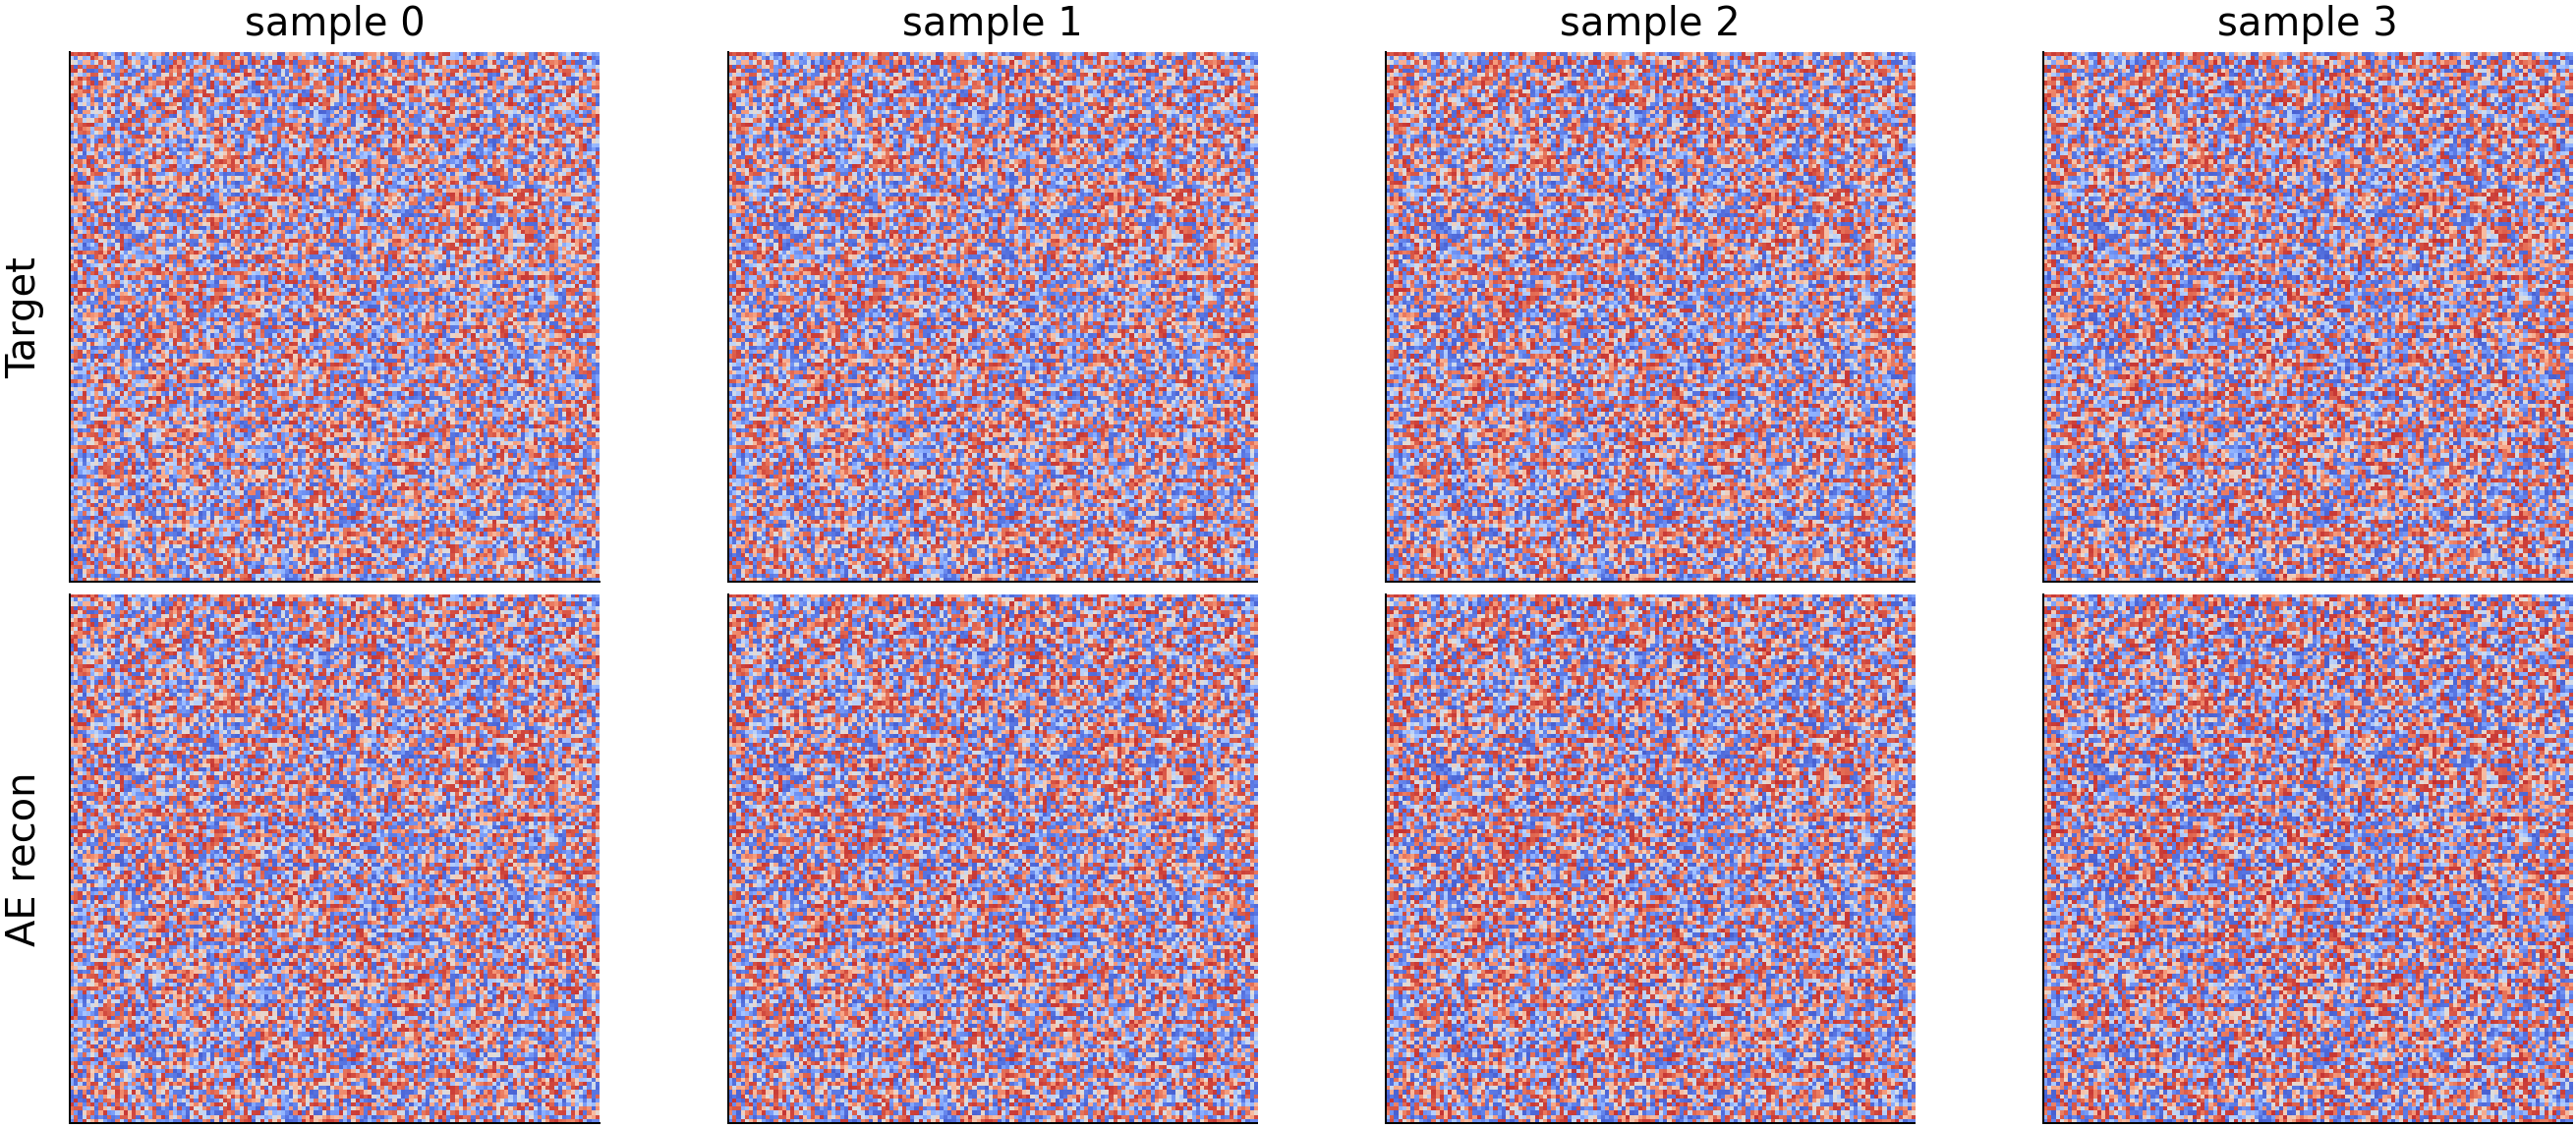

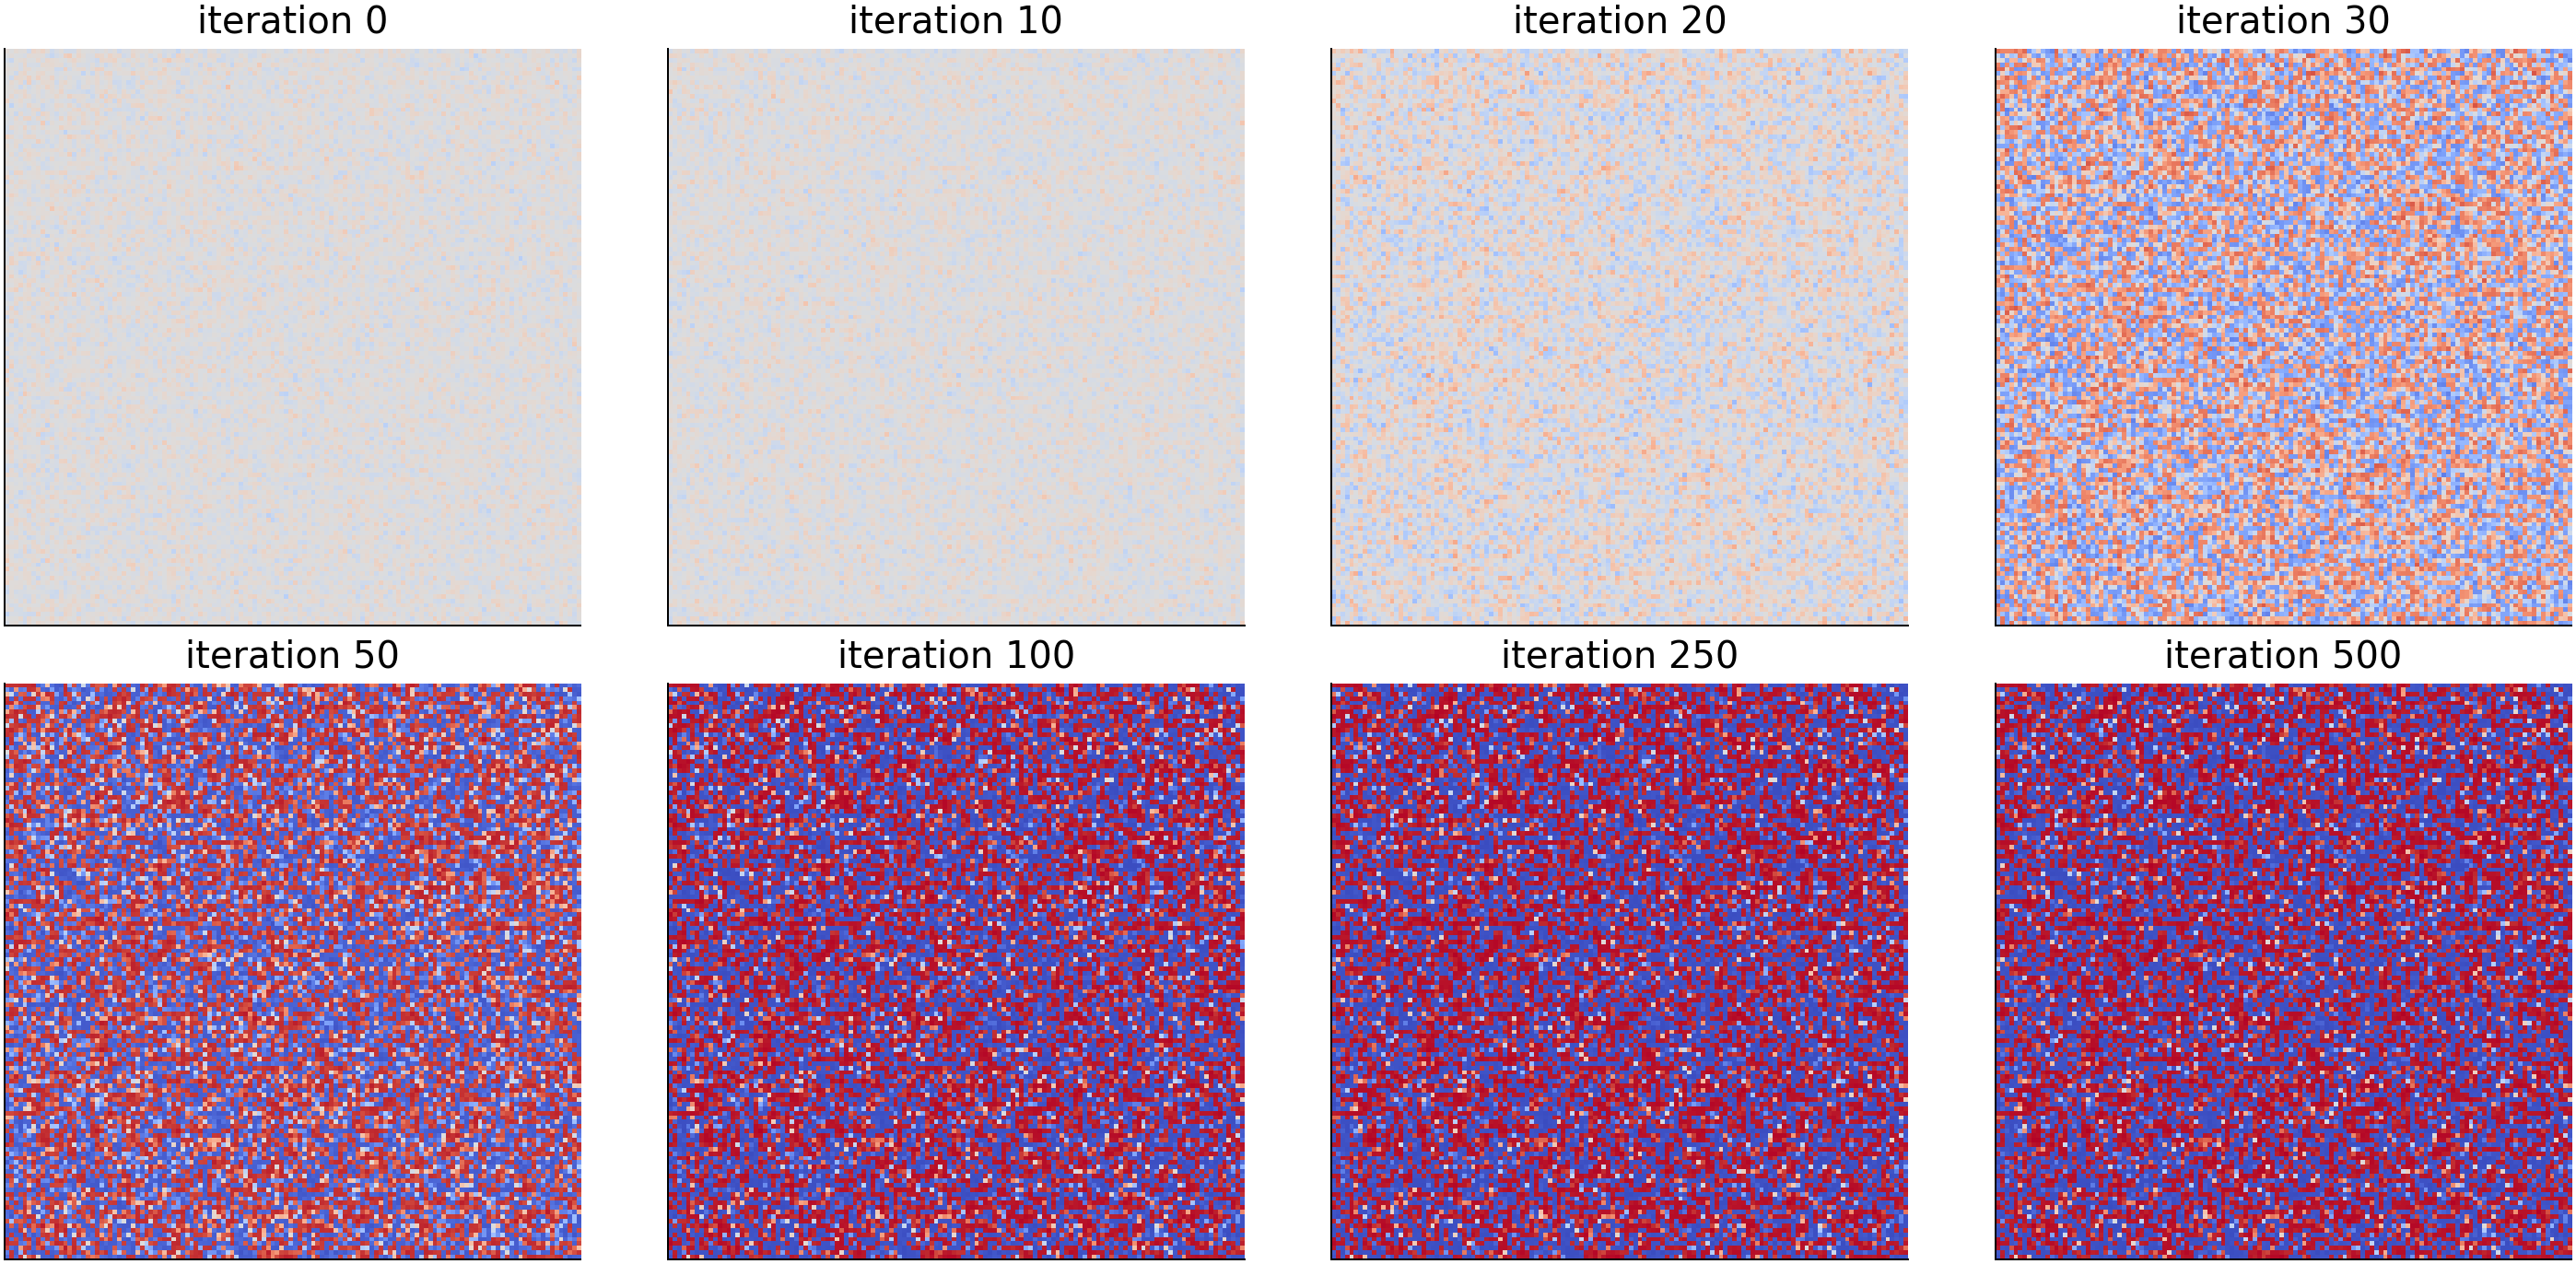

In [13]:
if plt is None:
    print('matplotlib is not installed; skipping sample field plots.')
else:
    # ============================================================
    # Visualization: decoded spatial fields
    # ============================================================
    # This cell is qualitative. It does not plot distributions.
    # Figure 1 checks whether the AE can reconstruct target fields.
    # Figure 2 follows one KSWGD particle through selected sampling iterations.

    field_title = 18
    row_label = 18
    tick_size = 14
    n_show = min(4, n_compare)

    # ---------- Figure 1: Target fields vs AE reconstructions ----------
    fig, axes = plt.subplots(2, n_show, figsize=(4.2 * n_show, 7.2), constrained_layout=True)
    if n_show == 1:
        axes = np.asarray(axes).reshape(2, 1)

    for j in range(n_show):
        axes[0, j].imshow(target_compare[j], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
        axes[0, j].set_title(f'sample {j}', fontsize=field_title, pad=8)
        axes[0, j].set_xticks([])
        axes[0, j].set_yticks([])

        axes[1, j].imshow(ae_recon_compare[j], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
        axes[1, j].set_xticks([])
        axes[1, j].set_yticks([])

    axes[0, 0].set_ylabel('Target', fontsize=row_label, labelpad=12)
    axes[1, 0].set_ylabel('AE recon', fontsize=row_label, labelpad=12)

    plt.show()

    # ---------- Figure 2: One KSWGD particle across sampling iterations ----------
    particle_idx = 0
    n_rows, n_cols = 2, 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8.6), constrained_layout=True)
    axes_flat = axes.ravel()

    for ax_idx, ax in enumerate(axes_flat):
        if ax_idx >= len(snapshot_steps_kswgd):
            ax.axis('off')
            continue
        step = snapshot_steps_kswgd[ax_idx]
        ax.imshow(decoded_by_step[step][particle_idx], cmap='coolwarm', origin='lower', vmin=-1, vmax=1, interpolation='nearest')
        ax.set_title(f'iteration {step}', fontsize=field_title, pad=8)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()


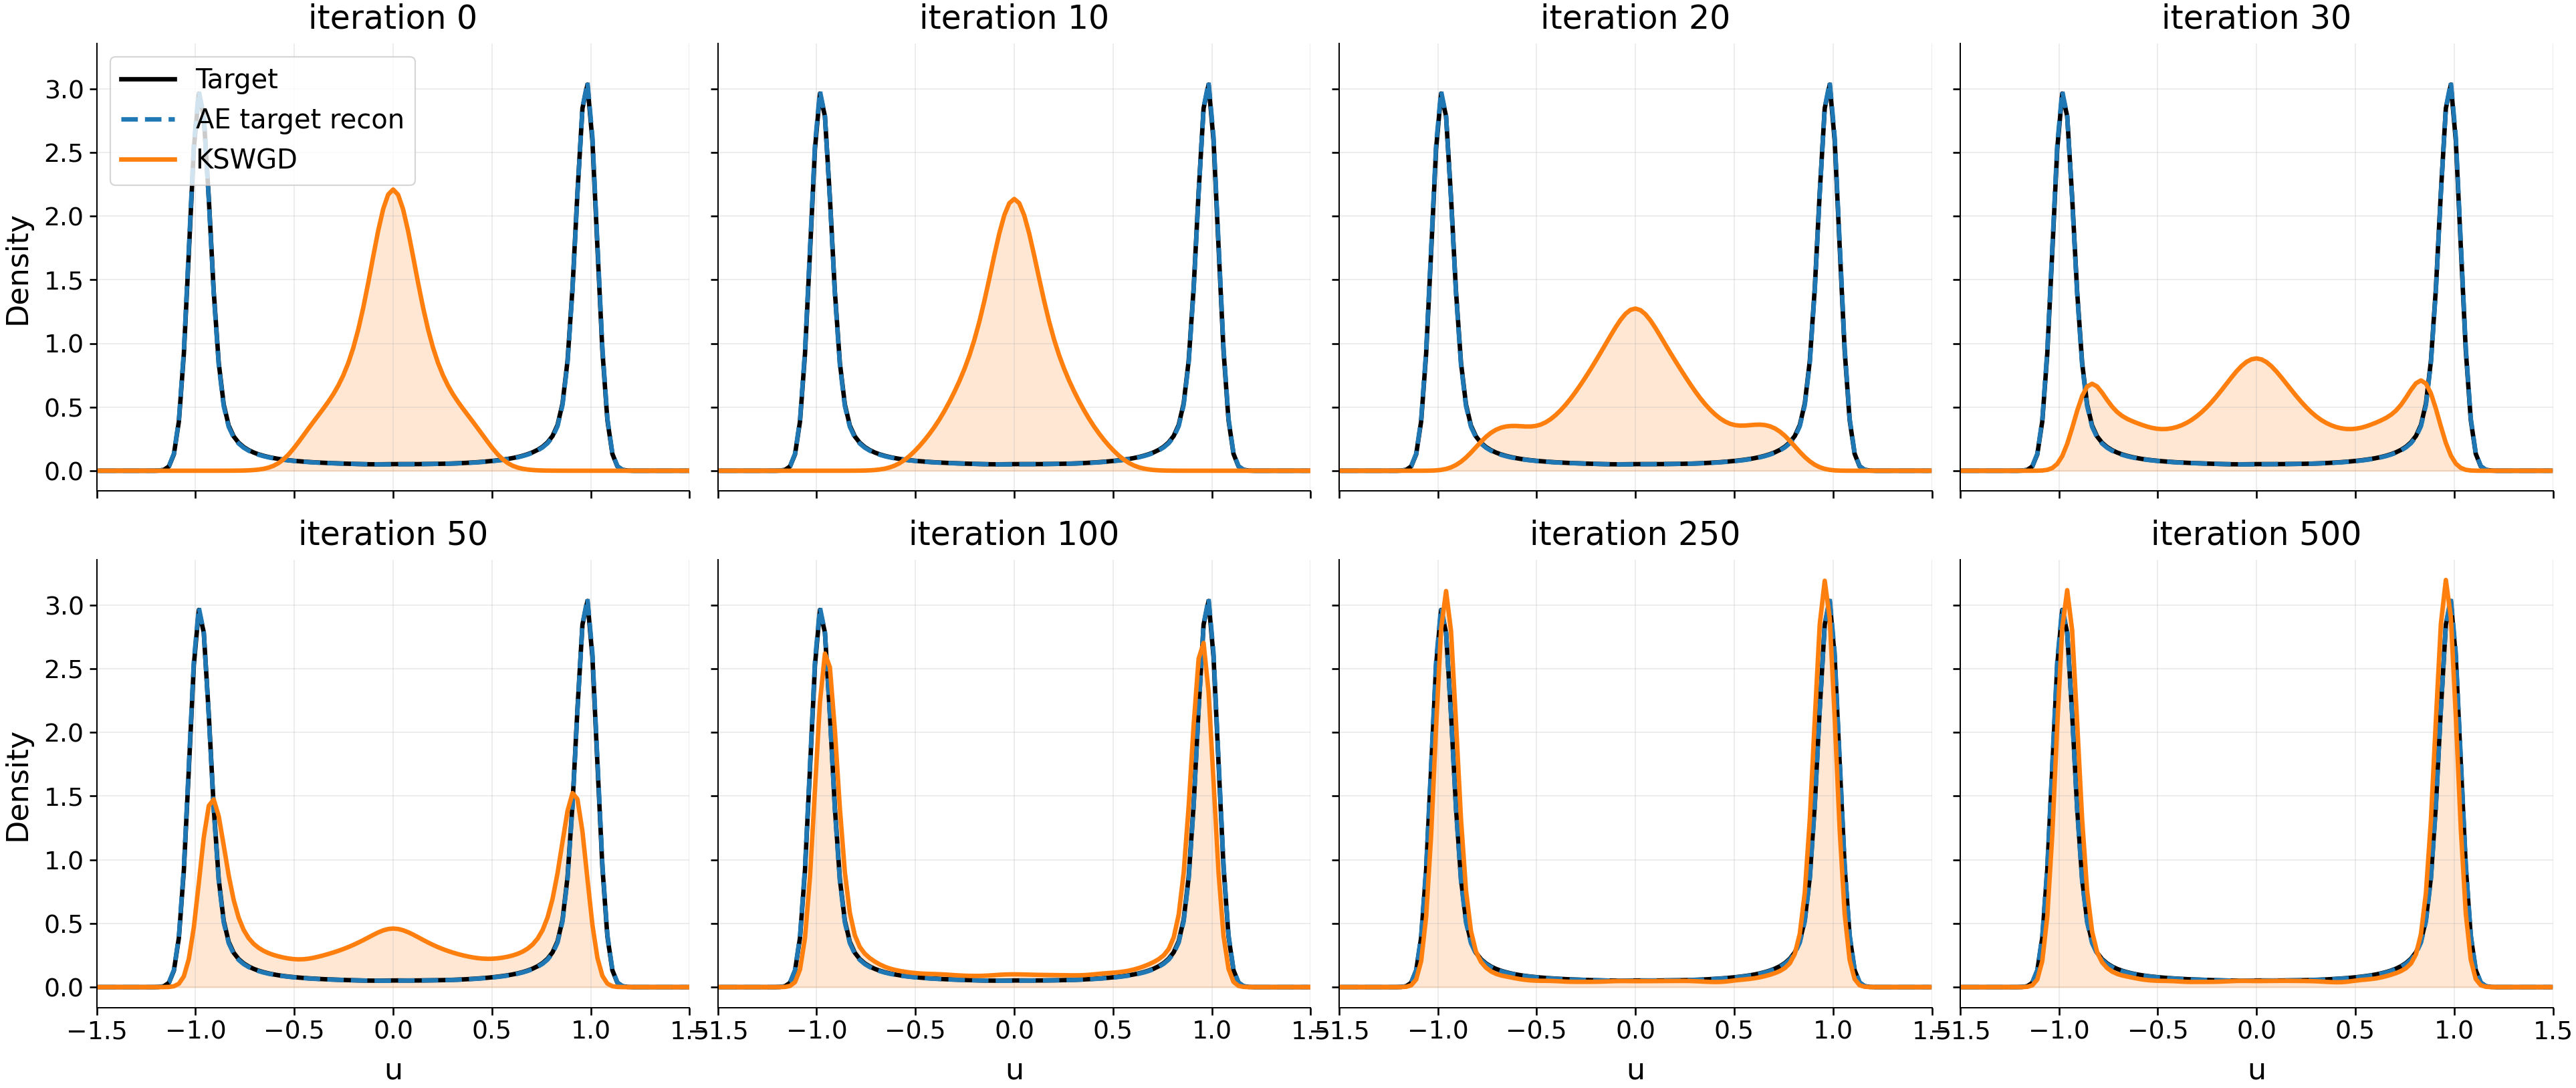

Saved: figures/allen_cahn/ac2_latent_sdmd_kswgd_histograms.png
Saved: figures/allen_cahn/ac2_latent_sdmd_kswgd_histograms.pdf


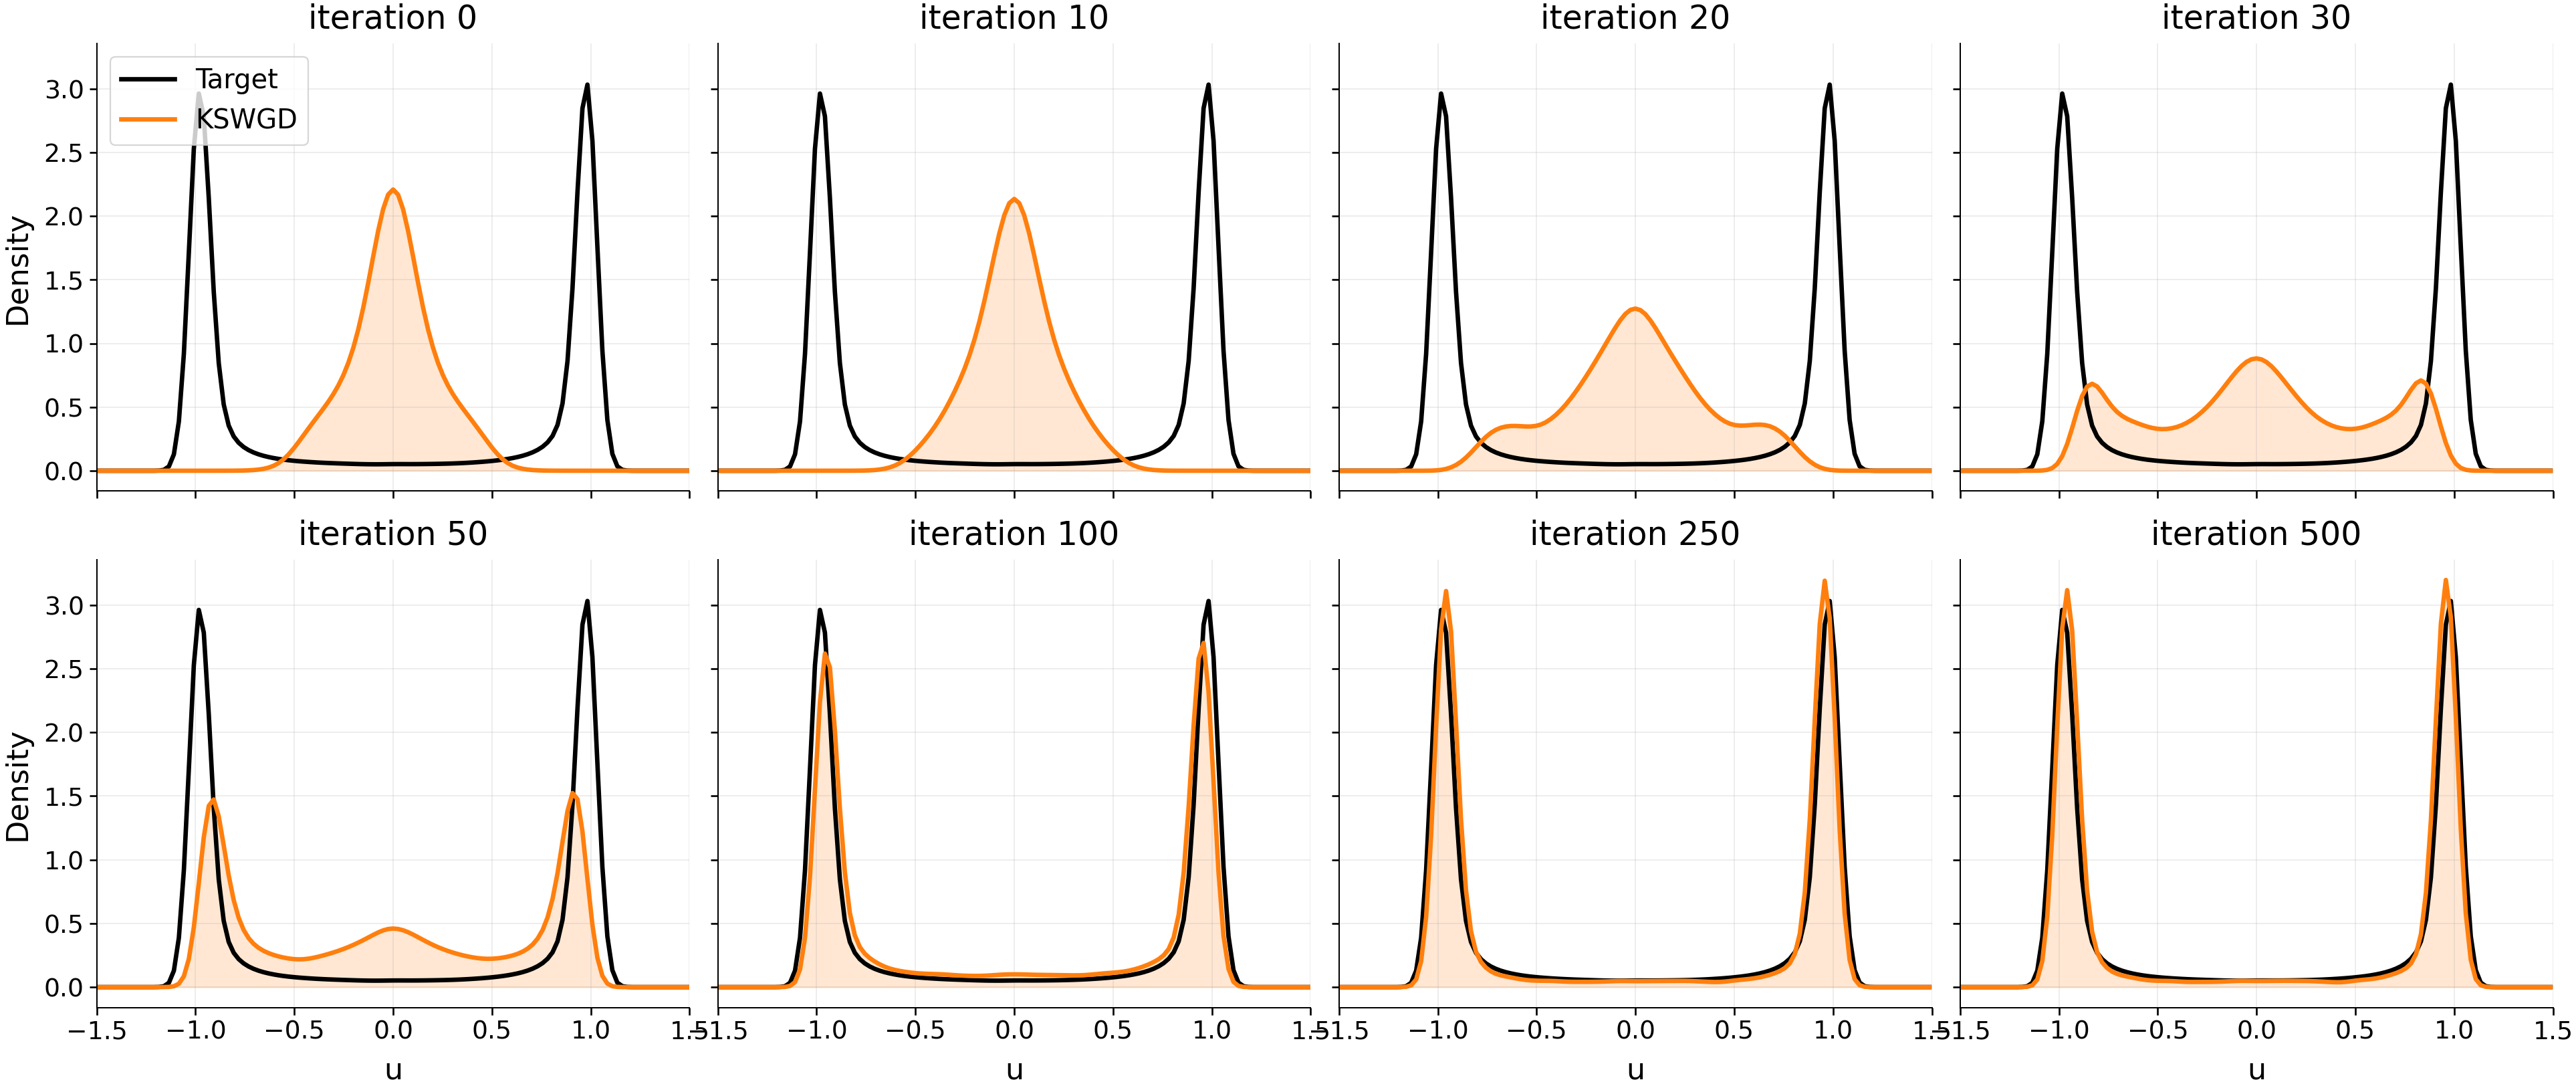

Saved: figures/allen_cahn/ac2_latent_sdmd_kswgd_histograms_no_ae_recon.png
Saved: figures/allen_cahn/ac2_latent_sdmd_kswgd_histograms_no_ae_recon.pdf


In [14]:
if plt is None:
    print('matplotlib is not installed; skipping histogram plot.')
else:
    # ============================================================
    # Visualization: pixel-value distributions
    # ============================================================
    # This cell compares one-dimensional histograms of all pixel values.
    # It is the main distribution-level diagnostic.

    bins = np.linspace(-1.5, 1.5, 120)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    smooth_sigma = 2

    font_title = 22
    font_label = 20
    font_tick = 17
    font_legend = 18
    line_width = 3.0

    target_hist, _ = np.histogram(target_compare.ravel(), bins=bins, density=True)
    target_hist = gaussian_filter1d(target_hist, sigma=smooth_sigma)
    recon_hist, _ = np.histogram(ae_recon_compare.ravel(), bins=bins, density=True)
    recon_hist = gaussian_filter1d(recon_hist, sigma=smooth_sigma)

    def plot_histogram_grid(include_ae_recon=True, filename_stem='ac2_latent_sdmd_kswgd_histograms'):
        n_rows, n_cols = 2, 4
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 10.5), sharex=True, sharey=True)
        axes_flat = axes.ravel()

        for ax_idx, ax in enumerate(axes_flat):
            if ax_idx >= len(snapshot_steps_kswgd):
                ax.axis('off')
                continue

            step = snapshot_steps_kswgd[ax_idx]
            gen = decoded_by_step[step]
            gen_hist, _ = np.histogram(gen.ravel(), bins=bins, density=True)
            gen_hist = gaussian_filter1d(gen_hist, sigma=smooth_sigma)

            ax.plot(bin_centers, target_hist, color='black', linewidth=line_width, label='Target')
            if include_ae_recon:
                ax.plot(bin_centers, recon_hist, color='#1f77b4', linewidth=line_width, linestyle='--', label='AE target recon')
            ax.plot(bin_centers, gen_hist, color='#ff7f0e', linewidth=line_width, label='KSWGD')
            ax.fill_between(bin_centers, gen_hist, color='#ff7f0e', alpha=0.18)
            ax.set_title(f'iteration {step}', fontsize=font_title, pad=10)
            ax.set_xlim(-1.5, 1.5)
            ax.grid(alpha=0.25)
            ax.tick_params(axis='both', labelsize=font_tick, width=1.2, length=5)

            if ax_idx // n_cols == n_rows - 1:
                ax.set_xlabel('u', fontsize=font_label, labelpad=8)
            if ax_idx % n_cols == 0:
                ax.set_ylabel('Density', fontsize=font_label, labelpad=8)

        axes_flat[0].legend(loc='upper left', fontsize=font_legend, frameon=True)
        plt.tight_layout(pad=1.4)
        fig_path_png = FIG_DIR / f'{filename_stem}.png'
        fig_path_pdf = FIG_DIR / f'{filename_stem}.pdf'
        plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
        plt.savefig(fig_path_pdf, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fig_path_png}')
        print(f'Saved: {fig_path_pdf}')

    plot_histogram_grid(include_ae_recon=True, filename_stem='ac2_latent_sdmd_kswgd_histograms')
    plot_histogram_grid(include_ae_recon=False, filename_stem='ac2_latent_sdmd_kswgd_histograms_no_ae_recon')


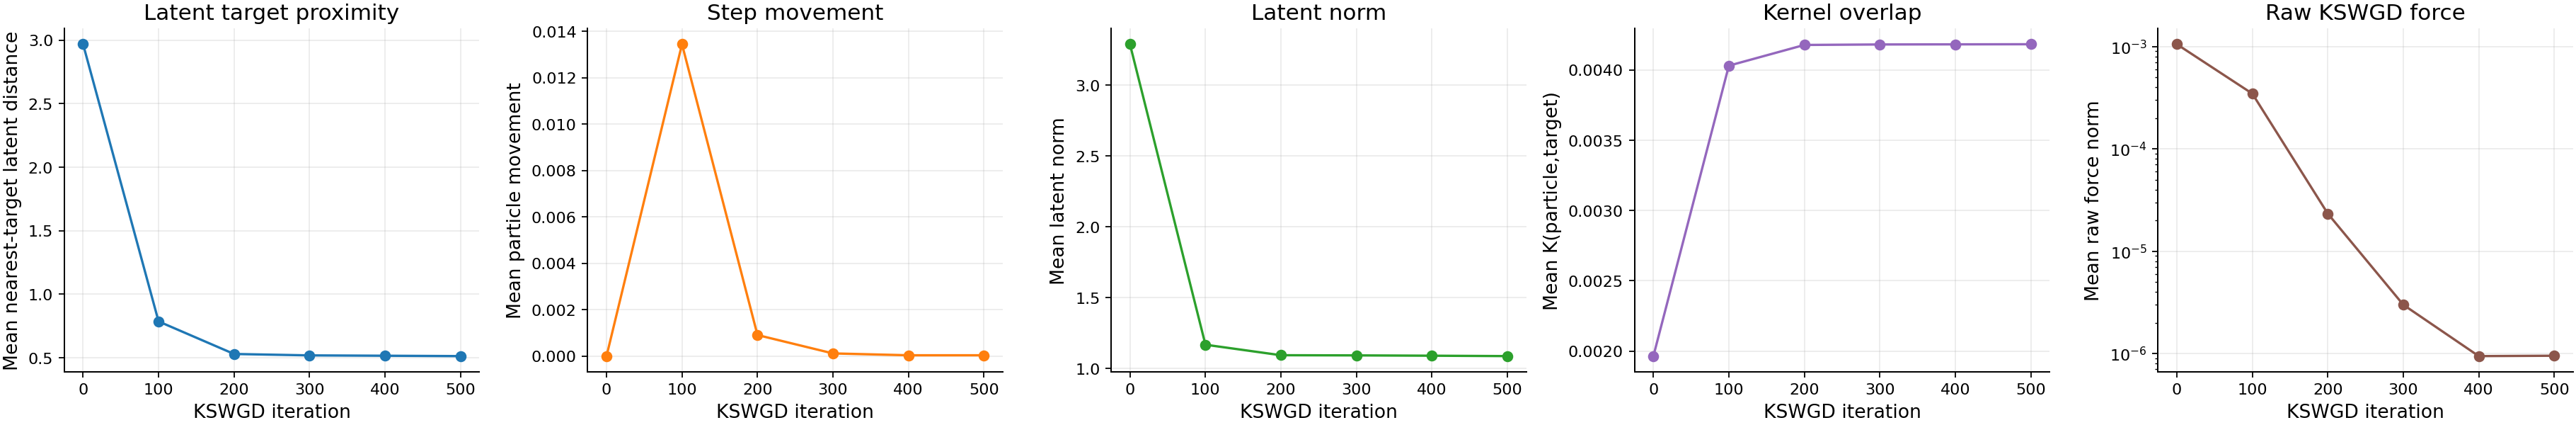

In [15]:
if plt is None:
    print('matplotlib is not installed; skipping metric plot.')
else:
    # ============================================================
    # Visualization: Latent convergence metrics
    # ============================================================

    fig, axes = plt.subplots(1, 5, figsize=(23, 4))

    axes[0].plot(metrics_sdmd['steps'], metrics_sdmd['target_nn_distance'], marker='o')
    axes[0].set_xlabel('KSWGD iteration')
    axes[0].set_ylabel('Mean nearest-target latent distance')
    axes[0].set_title('Latent target proximity')
    axes[0].grid(alpha=0.25)

    axes[1].plot(metrics_sdmd['steps'], metrics_sdmd['movement_rate'], marker='o', color='#ff7f0e')
    axes[1].set_xlabel('KSWGD iteration')
    axes[1].set_ylabel('Mean particle movement')
    axes[1].set_title('Step movement')
    axes[1].grid(alpha=0.25)

    axes[2].plot(metrics_sdmd['steps'], metrics_sdmd['mean_norm'], marker='o', color='#2ca02c')
    axes[2].set_xlabel('KSWGD iteration')
    axes[2].set_ylabel('Mean latent norm')
    axes[2].set_title('Latent norm')
    axes[2].grid(alpha=0.25)

    axes[3].plot(metrics_sdmd['steps'], metrics_sdmd['kernel_mean'], marker='o', color='#9467bd')
    axes[3].set_xlabel('KSWGD iteration')
    axes[3].set_ylabel('Mean K(particle,target)')
    axes[3].set_title('Kernel overlap')
    axes[3].grid(alpha=0.25)

    axes[4].plot(metrics_sdmd['steps'], metrics_sdmd['force_norm'], marker='o', color='#8c564b')
    axes[4].set_xlabel('KSWGD iteration')
    axes[4].set_ylabel('Mean raw force norm')
    axes[4].set_title('Raw KSWGD force')
    axes[4].set_yscale('log')
    axes[4].grid(alpha=0.25)

    plt.tight_layout(pad=1.1)
    plt.show()


In [16]:
# # ============================================================
# # Save compact result bundle for later inspection
# # ============================================================

# result_path = FIG_DIR / 'ac_latent_sdmd_kswgd_results.npz'
# np.savez_compressed(
#     result_path,
#     snapshot_times=snapshot_times,
#     Z_tar=Z_tar,
#     Z_tar_next=Z_tar_next,
#     Z_init=Z_init,
#     Z_final=Z_kswgd_traj_sdmd[:, :, -1],
#     metrics_steps=metrics_sdmd['steps'],
#     metrics_target_nn_distance=metrics_sdmd['target_nn_distance'],
#     metrics_movement_rate=metrics_sdmd['movement_rate'],
#     metrics_kernel_mean=metrics_sdmd['kernel_mean'],
#     metrics_kernel_max=metrics_sdmd['kernel_max'],
#     metrics_force_norm=metrics_sdmd['force_norm'],
#     metrics_effective_step_size=metrics_sdmd['effective_step_size'],
#     latent_shift=latent_shift,
#     latent_scale=latent_scale,
#     Z_tar_raw=Z_tar_raw,
#     Z_init_raw=from_kswgd_latent(Z_init),
#     eigvals_K_sdmd=eigvals_K_sdmd,
#     lambda_gen_full_sdmd=lambda_gen_full_sdmd,
# )
# print(f'Saved compact results: {result_path}')
